# Notebook to process lysosomal and mitochondrial morphology from cellprofiler features - this time from a merged cell CSV aready created
Inputs Required
 - Database with cellprofiler outputs
   - Mainly use the Per_Cell table for per-cell features
     - Intensity
     - AreaShape features
     - Ratio of organelle area to total cell area
     - Texture features
     - Granularity features
     - Radial intensity distribution about nucleus
   - May additionally want to use mitochdondria or lysosomes.csv if analyzing these specifically 
     - Note that lysosome segmentation is not perfect (but i'm proud of it)
 - Metadata CSV representing 96-well platemap
   - Long-form table containing passage number, staining conditons, treatments, etc
   - Produced automatically from an 8x12 table with the 96Well_PlateMap code
Outputs
- graphs for individual features
- clustering
## Set your paths here

In [6]:
# Imports
import os
from pathlib import Path
import numpy as np
import pandas as pd
import sqlite3

# plotting
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt

%matplotlib inline
import seaborn as sns
import pingouin as pg
import re

from scipy import stats

from plate_information import *
from plate_preprocessing import *
from mitolyso_plot_functions import *

## Import the big csv

In [7]:
# import from a giant csv
# csvpath = "/Volumes/AllieS/Morphology_data/"

# csvpath = "/Volumes/AllieS/2025_OrganelleMorphology_MitoLyso/test_mitoimprov_v5"
csvpath = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/mito_seg_testing/mitoimprov_v7"
filename = "Cell.csv"
# filename = "total_combined_cell_borders_excluded.csv"

cell_df_mitolyso = pd.read_csv(os.path.join(csvpath, filename))
nuc_df_mitolyso = pd.read_csv(os.path.join(csvpath, "Nuclei.csv"))
# image_df = pd.read_csv(os.path.join(csvpath, "Image.csv"))
combined_cell_df_mitolyso = pd.merge(
    cell_df_mitolyso,
    nuc_df_mitolyso,
    left_on=["ImageNumber", "Parent_Nuclei"],
    right_on=["ImageNumber", "ObjectNumber"],
    suffixes=("", "_Nuclei"),
    how="left",
)
# combined_cell_df_mitolyso = pd.merge(combined_cell_df_mitolyso, image_df, left_on=["ImageNumber"], right_on=["ImageNumber"], suffixes=("", "_Image"))
# filter_df = enforce_objects_one_to_one(combined_cell_df_mitolyso)
display(f"cell_df_mitolyso.shape: {cell_df_mitolyso.shape}")
display(f"combined_cell_df_mitolyso.shape: {combined_cell_df_mitolyso.shape}")
# print(cell_df.shape, " ", filter_df.shape)


'cell_df_mitolyso.shape: (600, 321)'

'combined_cell_df_mitolyso.shape: (600, 503)'

In [8]:
#add metadata columns for merging with metadata csv
combined_cell_df_mitolyso["Metadata_RowColField"] = (
    "r"
    + combined_cell_df_mitolyso["Metadata_WellRow"].astype(str).str.rjust(2, "0")
    + "c"
    + combined_cell_df_mitolyso["Metadata_WellColumn"].astype(str).str.rjust(2, "0")
    + "f"
    + combined_cell_df_mitolyso["Metadata_Field"].astype(str).str.rjust(2, "0")
)

combined_cell_df_mitolyso["Metadata_Rep_RowColField"] = (
    "rep"
    + combined_cell_df_mitolyso["Metadata_PlateNumber"].astype(str).str.rjust(2, "0")
    + "_"
    + combined_cell_df_mitolyso["Metadata_RowColField"]
)

combined_cell_df_mitolyso["Metadata_PlateNumber"] = combined_cell_df_mitolyso[
    "Metadata_PlateNumber"
].astype(str)

display(f"combined_cell_df_mitolyso.shape before metadata merge: {combined_cell_df_mitolyso.shape}")

metadata_path = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/Reworking_MitoSegmentation/MitochondriaSegmentationSubsetImages_metaonly.csv"
metadata_df = pd.read_csv(metadata_path)
metadata_df["Metadata_PlateNumber"] = metadata_df["Metadata_PlateNumber"].astype(str)
metadata_df["Metadata_RowColField"] = metadata_df["Metadata_RowColField"].astype(str)

keys = ["Metadata_PlateNumber", "Metadata_RowColField"] #, "ObjectNumber"]
display(metadata_df.head())
combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    metadata_df,
    on=keys,
    how="left",
)
display(
    f"combined_cell_df_mitolyso.shape after metadata merge: {combined_cell_df_mitolyso.shape}"
)
display(combined_cell_df_mitolyso.tail())

'combined_cell_df_mitolyso.shape before metadata merge: (600, 505)'

,AllGroups,Metadata_PlateNumber,Image_FileName_MitoTracker_MAX,Metadata_RowColField,Value
0,P13-15,6,MAX_ch2-r07c11f26.tif,r07c11f26,Lowest
1,P13-15,6,MAX_ch2-r07c10f33.tif,r07c10f33,Lowest
2,P13-15,6,MAX_ch2-r07c10f17.tif,r07c10f17,bog standard
3,P13-15,6,MAX_ch2-r07c10f03.tif,r07c10f03,Lowest
4,P13-15,1,MAX_ch2-r07c04f15.tif,r07c04f15,Lowest


'combined_cell_df_mitolyso.shape after metadata merge: (600, 508)'

,ImageNumber,ObjectNumber,Metadata_C,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_Field,Metadata_Field.1,Metadata_FileLocation,Metadata_Frame,...,ObjectSkeleton_NumberTrunks_MitoSkel1,ObjectSkeleton_NumberTrunks_MitoSkel2,ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel1,ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2,Parent_AllNuclei,Metadata_RowColField,Metadata_Rep_RowColField,AllGroups,Image_FileName_MitoTracker_MAX,Value
595,96,9,0,NaN,NaN,monochrome,39,39,NaN,0,...,20,14,1533.692586,3789.528538,9,r05c11f39,rep07_r05c11f39,P13-15,MAX_ch2-r05c11f39.tif,higher
596,96,10,0,NaN,NaN,monochrome,39,39,NaN,0,...,14,15,1278.106791,1564.878440,10,r05c11f39,rep07_r05c11f39,P13-15,MAX_ch2-r05c11f39.tif,higher
597,96,11,0,NaN,NaN,monochrome,39,39,NaN,0,...,8,9,1012.065154,1865.856151,12,r05c11f39,rep07_r05c11f39,P13-15,MAX_ch2-r05c11f39.tif,higher
598,96,12,0,NaN,NaN,monochrome,39,39,NaN,0,...,13,13,2535.235889,1298.592080,11,r05c11f39,rep07_r05c11f39,P13-15,MAX_ch2-r05c11f39.tif,higher
599,96,13,0,NaN,NaN,monochrome,39,39,NaN,0,...,19,19,1196.124037,1358.545395,13,r05c11f39,rep07_r05c11f39,P13-15,MAX_ch2-r05c11f39.tif,higher


In [9]:
# Join another csv with data on the same cells with the ImageJ features
csvpath_1 = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/mito_seg_testing/test_ijskeleton/out_v1/testdata1.csv"
csvpath_2 = "/mnt/bigdisk1/AllieSpangaro/Morphology_Replicative_Age_Project/CP_Output/mito_seg_testing/test_ijskeleton/out_v2/testdata2.csv"

ij_skeleton_df_1 = pd.read_csv(csvpath_1)
ij_skeleton_df_2 = pd.read_csv(csvpath_2)

ij_skeleton_df_1["Metadata_PlateNumber"] = ij_skeleton_df_1["Metadata_PlateNumber"].astype(
    str
)
ij_skeleton_df_2["Metadata_PlateNumber"] = ij_skeleton_df_2[
    "Metadata_PlateNumber"
].astype(str)

display(ij_skeleton_df_1.head())
display(combined_cell_df_mitolyso.shape)

ij_skeleton_combined = pd.merge(
    ij_skeleton_df_1,
    ij_skeleton_df_2,
    left_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    right_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    how="left",
    suffixes=("_IJ1", "_IJ2"),
)

combined_cell_df_mitolyso = pd.merge(
    combined_cell_df_mitolyso,
    ij_skeleton_combined,
    left_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    right_on=["Metadata_PlateNumber", "Metadata_RowColField", "ObjectNumber"],
    how="left",
)


display(combined_cell_df_mitolyso.shape)
display(combined_cell_df_mitolyso.head())

,image title,ObjectNumber,Metadata_PlateNumber,Metadata_RowColField,thresholding op,branch length mean,branch length median,branch length stdev,summed branch lengths mean,summed branch lengths median,summed branch lengths stdev,network branches mean,network branches median,network branches stdev,total skeleton length,total triple points,cumulative longest shortest path length,donuts
0,rep06_MAX_ch2-r01c07f14_RelabeledMitoV1_1.tiff,1,6,r01c07f14,otsu,15.839,11.899,12.322,178.751,4.500,516.255,11.286,1.0,30.740,2502.519,77,626.108,0
1,rep06_MAX_ch2-r01c07f14_RelabeledMitoV1_3.tiff,3,6,r01c07f14,otsu,13.852,10.899,11.331,268.201,7.000,2017.669,19.362,1.0,143.933,18505.872,668,3161.529,0
2,rep06_MAX_ch2-r01c07f14_RelabeledMitoV1_2.tiff,2,6,r01c07f14,otsu,16.694,10.450,17.953,77.907,9.950,117.164,4.667,1.0,7.846,1402.334,33,890.786,0
3,rep05_MAX_ch2-r04c01f16_RelabeledMitoV1_1.tiff,1,5,r04c01f16,otsu,12.973,10.657,9.553,155.889,3.828,1540.806,12.016,1.0,117.064,19330.204,721,2762.867,0
4,rep05_MAX_ch2-r04c01f16_RelabeledMitoV1_2.tiff,2,5,r04c01f16,otsu,19.794,13.485,17.632,192.445,6.743,752.571,9.722,1.0,35.724,3464.015,84,609.952,0


(600, 508)

(600, 538)

,ImageNumber,ObjectNumber,Metadata_C,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_Field,Metadata_Field.1,Metadata_FileLocation,Metadata_Frame,...,summed branch lengths mean_IJ2,summed branch lengths median_IJ2,summed branch lengths stdev_IJ2,network branches mean_IJ2,network branches median_IJ2,network branches stdev_IJ2,total skeleton length_IJ2,total triple points_IJ2,cumulative longest shortest path length_IJ2,donuts_IJ2
0,1,1,0,NaN,NaN,monochrome,23,23,NaN,0,...,55.227,6.243,490.367,6.133,1.0,53.654,9112.409,412,2555.876,4
1,2,1,0,NaN,NaN,monochrome,16,16,NaN,0,...,163.395,6.657,1451.362,13.000,1.0,112.887,20751.209,780,3949.940,1
2,2,2,0,NaN,NaN,monochrome,16,16,NaN,0,...,390.141,3.000,1494.140,32.062,1.0,120.563,6242.255,239,583.191,0
3,3,1,0,NaN,NaN,monochrome,4,4,NaN,0,...,202.529,17.642,1166.575,20.364,1.5,118.699,13366.923,572,3016.847,1
4,3,2,0,NaN,NaN,monochrome,4,4,NaN,0,...,302.953,9.450,1153.399,35.667,1.0,133.624,5453.150,271,728.123,0


## Setup functions


### Filter out the poorly segmented cells and rename the columns so I don't have to change the old code

## Search Column Names

In [5]:
# colnames
# sns.barplot(filter_df_2, x="AllGroups",y="AreaShape_Area", hue="Plate_Number", palette=colour_dict)
colnames = search_column_name(combined_cell_df_mitolyso, "Number")
display(combined_cell_df_mitolyso[colnames + ["image title"]])

Query: Number
    ImageNumber
    ObjectNumber
    Metadata_PlateNumber
    Metadata_PlateNumber.1
    AreaShape_EulerNumber
    AreaShape_EulerNumber.1
    Mean_MitoSkelV1Seeds_Number_Object_Number
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel1
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberTrunks_MitoSkel1
    Mean_MitoSkelV2Seeds_Number_Object_Number
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel2
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberTrunks_MitoSkel2
    Mean_RelabeledMitoV1_AreaShape_EulerNumber
    Mean_RelabeledMitoV1_Number_Object_Number
    Mean_RelabeledMitoV2_AreaShape_EulerNumber
    Mean_RelabeledMitoV2_Number_Object_Number
    Number_Object_Number
    Number_Object_Number.1
    ObjectNumber_Nuclei
    Metadata_PlateNumber_Nuclei
    Metadata_PlateNumber.1_Nuclei
    AreaShape_EulerNu

,ImageNumber,ObjectNumber,Metadata_PlateNumber,Metadata_PlateNumber.1,AreaShape_EulerNumber,AreaShape_EulerNumber.1,Mean_MitoSkelV1Seeds_Number_Object_Number,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel1,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberTrunks_MitoSkel1,...,AreaShape_EulerNumber_Nuclei,AreaShape_EulerNumber.1_Nuclei,Number_Object_Number_Nuclei,ObjectSkeleton_NumberBranchEnds_MitoSkel1,ObjectSkeleton_NumberBranchEnds_MitoSkel2,ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1,ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2,ObjectSkeleton_NumberTrunks_MitoSkel1,ObjectSkeleton_NumberTrunks_MitoSkel2,image title
0,1,1,5,5,1,1,2257.562392,0.052860,0.433276,0.628250,...,1,1,1,143.0,54.0,282.0,275.0,43,39,rep05_MAX_ch2-r02c01f23_RelabeledMitoV1_1.tiff
1,2,1,5,5,1,1,1014.704718,0.112633,1.325723,0.908676,...,1,1,1,342.0,148.0,713.0,606.0,38,36,rep05_MAX_ch2-r04c01f16_RelabeledMitoV1_1.tiff
2,2,2,5,5,1,1,1387.000000,0.023438,0.773438,0.757812,...,1,1,2,42.0,61.0,78.0,248.0,14,17,rep05_MAX_ch2-r04c01f16_RelabeledMitoV1_2.tiff
3,3,1,5,5,1,1,252.831933,0.098039,0.764706,0.820728,...,1,1,1,82.0,90.0,127.0,324.0,25,29,rep05_MAX_ch2-r05c01f04_RelabeledMitoV1_1.tiff
4,3,2,5,5,1,1,293.647059,0.044118,0.132353,0.617647,...,1,1,2,0.0,41.0,0.0,148.0,0,23,rep05_MAX_ch2-r05c01f04_RelabeledMitoV1_2.tiff
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,96,9,7,7,1,1,1859.880000,0.024000,0.640000,0.856000,...,1,1,9,30.0,57.0,59.0,275.0,20,14,rep07_MAX_ch2-r05c11f39_RelabeledMitoV1_9.tiff
596,96,10,7,7,1,1,1982.729730,0.135135,1.324324,1.081081,...,1,1,10,30.0,26.0,44.0,71.0,14,15,rep07_MAX_ch2-r05c11f39_RelabeledMitoV1_10.tiff
597,96,11,7,7,1,1,2254.145161,0.112903,0.693548,0.774194,...,1,1,12,19.0,30.0,23.0,96.0,8,9,rep07_MAX_ch2-r05c11f39_RelabeledMitoV1_11.tiff
598,96,12,7,7,1,1,2263.895522,0.029851,0.880597,0.925373,...,1,1,11,53.0,22.0,101.0,52.0,13,13,rep07_MAX_ch2-r05c11f39_RelabeledMitoV1_12.tiff


In [ ]:
def fix_column_names(df, suffix, extrasuffix=""):
    # transform the MitoSkel{suffix}Seeds - number of ends times the mean to get total per cell
    df[f"Per_Area_AreaOccupied_RelabeledMitoV{suffix}{extrasuffix}_AreaShape_Area"] = (
        df[f"Mean_RelabeledMitoV{suffix}{extrasuffix}_AreaShape_Area"]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_Children_SplitMaskedMito_v{suffix}{extrasuffix}_Count"] = (
        df[f"Children_SplitMaskedMito_v{suffix}{extrasuffix}_Count"]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_MitoSkelV{suffix}Seeds{extrasuffix}_Endpoints_Count"] = (
        df[f"Children_MitoSkelV{suffix}Seeds{extrasuffix}_Count"]
        / df["AreaShape_Area"]
    )
    
    # for mito skel seeded version, multiply the mean by the count to get total per cell, then divide by area
    df[
        f"Math_Total_NumberBranchEnds_MitoSkelV{suffix}Seeds{extrasuffix}"
    ] = (
        df[f"Children_MitoSkelV{suffix}Seeds{extrasuffix}_Count"]
        * df[
            f"Mean_MitoSkelV{suffix}Seeds{extrasuffix}_ObjectSkeleton_NumberBranchEnds_MitoSkel{suffix}{extrasuffix}"
        ]
    )
    df[
        f"Math_Total_NumberNonTrunkBranches_MitoSkelV{suffix}Seeds{extrasuffix}"
    ] = (
        df[f"Children_MitoSkelV{suffix}Seeds{extrasuffix}_Count"]
        * df[
            f"Mean_MitoSkelV{suffix}Seeds{extrasuffix}_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel{suffix}{extrasuffix}"
        ]
    )
    df[
        f"Math_Total_NumberTrunks_MitoSkelV{suffix}Seeds{extrasuffix}"
    ] = (
        df[f"Children_MitoSkelV{suffix}Seeds{extrasuffix}_Count"]
        * df[
            f"Mean_MitoSkelV{suffix}Seeds{extrasuffix}_ObjectSkeleton_NumberTrunks_MitoSkel{suffix}{extrasuffix}"
        ]
    )
    df[
        f"Math_TotalObjectSkeletonLength_MitoSkelV{suffix}Seeds{extrasuffix}"
    ] = (
        df[f"Children_MitoSkelV{suffix}Seeds{extrasuffix}_Count"]
        * df[
            f"Mean_MitoSkelV{suffix}Seeds{extrasuffix}_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel{suffix}{extrasuffix}"
        ]
    )
    # now divide these by cell area
    df[f"Per_Area_MitoSkelV{suffix}Seeds{extrasuffix}_NumberBranchEnds"] = (
        df[
            f"Math_Total_NumberBranchEnds_MitoSkelV{suffix}Seeds{extrasuffix}"
        ]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_MitoSkelV{suffix}Seeds{extrasuffix}_NumberNonTrunkBranches"] = (
        df[
            f"Math_Total_NumberNonTrunkBranches_MitoSkelV{suffix}Seeds{extrasuffix}"
        ]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_MitoSkelV{suffix}Seeds{extrasuffix}_NumberTrunks"] = (
        df[
            f"Math_Total_NumberTrunks_MitoSkelV{suffix}Seeds{extrasuffix}"
        ]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_MitoSkelV{suffix}Seeds{extrasuffix}_TotalObjectSkeletonLength"] = (
        df[
            f"Math_TotalObjectSkeletonLength_MitoSkelV{suffix}Seeds{extrasuffix}"
        ]
        / df["AreaShape_Area"]
    )

    # for nucleus seeded version
    df[f"Per_Area_FromNucleus_ObjectSkeleton_NumberBranchEnds_MitoSkel{suffix}"] = (
        df[f"ObjectSkeleton_NumberBranchEnds_MitoSkel{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_FromNucleus_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel{suffix}"] = (
        df[f"ObjectSkeleton_NumberNonTrunkBranches_MitoSkel{suffix}"]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_FromNucleus_ObjectSkeleton_NumberTrunks_MitoSkel{suffix}"] = (
        df[f"ObjectSkeleton_NumberTrunks_MitoSkel{suffix}"]
        / df["AreaShape_Area"]
    )
    df[f"Per_Area_FromNucleus_TotalObjectSkeletonLength_MitoSkel{suffix}"] = (
        df[f"ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel{suffix}"]
        / df["AreaShape_Area"]
    )
    
    # for extra features per area
    df[f"Per_Area_IJ_branch_length_mean_{suffix}"] = (
        df[f"branch length mean_IJ{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_IJ_branch_length_median_{suffix}"] = (
        df[f"branch length median_IJ{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_IJ_branch_length_stdev_{suffix}"] = (
        df[f"branch length stdev_IJ{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_IJ_summed_branch_length_mean_{suffix}"] = (
        df[f"summed branch lengths mean_IJ{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_IJ_summed_branch_length_median_{suffix}"] = (
        df[f"summed branch lengths median_IJ{suffix}"] / df["AreaShape_Area"]
    )
    df[f"Per_Area_IJ_summed_branch_length_stdev_{suffix}"] = (
        df[f"summed branch lengths stdev_IJ{suffix}"] / df["AreaShape_Area"]
    )


    return df


combined_cell_df_mitolyso2 = fix_column_names(combined_cell_df_mitolyso, suffix=1)
combined_cell_df_mitolyso2 = fix_column_names(combined_cell_df_mitolyso2, suffix=2)
# combined_cell_df_mitolyso2 = fix_column_names(
#     combined_cell_df_mitolyso2, suffix=1, extrasuffix="_BleedCorrected"
# )
# combined_cell_df_mitolyso3 = fix_column_names(
#     combined_cell_df_mitolyso2, suffix=2, extrasuffix="_BleedCorrected"
# )
display(combined_cell_df_mitolyso2.tail())
colnames_object_skeleton = search_column_name(combined_cell_df_mitolyso2, "ObjectSkeleton")
colnames_per_area = search_column_name(combined_cell_df_mitolyso2, "Per_Area")
colnames_totals = search_column_name(combined_cell_df_mitolyso2, "Math_Total")
display(combined_cell_df_mitolyso2[colnames_object_skeleton])

,ImageNumber,ObjectNumber,Metadata_C,Metadata_Channel,Metadata_ChannelName,Metadata_ColorFormat,Metadata_Field,Metadata_Field.1,Metadata_FileLocation,Metadata_Frame,...,Per_Area_FromNucleus_ObjectSkeleton_NumberBranchEnds_MitoSkel2,Per_Area_FromNucleus_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2,Per_Area_FromNucleus_ObjectSkeleton_NumberTrunks_MitoSkel2,Per_Area_FromNucleus_TotalObjectSkeletonLength_MitoSkel2,Per_Area_IJ_branch_length_mean_2,Per_Area_IJ_branch_length_median_2,Per_Area_IJ_branch_length_stdev_2,Per_Area_IJ_summed_branch_length_mean_2,Per_Area_IJ_summed_branch_length_median_2,Per_Area_IJ_summed_branch_length_stdev_2
595,96,9,0,NaN,NaN,monochrome,39,39,NaN,0,...,0.000607,0.002928,0.000149,0.040347,0.000105,0.000084,0.000084,0.001382,0.000051,0.006014
596,96,10,0,NaN,NaN,monochrome,39,39,NaN,0,...,0.000450,0.001228,0.000259,0.027072,0.000203,0.000141,0.000177,0.001442,0.000177,0.004748
597,96,11,0,NaN,NaN,monochrome,39,39,NaN,0,...,0.000477,0.001528,0.000143,0.029698,0.000173,0.000135,0.000149,0.003055,0.000304,0.009600
598,96,12,0,NaN,NaN,monochrome,39,39,NaN,0,...,0.000295,0.000698,0.000175,0.017435,0.000190,0.000140,0.000156,0.001304,0.000201,0.003354
599,96,13,0,NaN,NaN,monochrome,39,39,NaN,0,...,0.000195,0.000526,0.000185,0.013239,0.000129,0.000110,0.000084,0.000889,0.000145,0.002845


Query: ObjectSkeleton
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel1
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1
    Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberTrunks_MitoSkel1
    Mean_MitoSkelV1Seeds_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel1
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel2
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2
    Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberTrunks_MitoSkel2
    Mean_MitoSkelV2Seeds_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2
    ObjectSkeleton_NumberBranchEnds_MitoSkel1
    ObjectSkeleton_NumberBranchEnds_MitoSkel2
    ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1
    ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2
    ObjectSkeleton_NumberTrunks_MitoSkel1
    ObjectSkeleton_NumberTrunks_MitoSkel2
    ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel1
    ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2
    Math_TotalObjectSkeletonLe

,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel1,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberTrunks_MitoSkel1,Mean_MitoSkelV1Seeds_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel1,Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel2,Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2,Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberTrunks_MitoSkel2,Mean_MitoSkelV2Seeds_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2,ObjectSkeleton_NumberBranchEnds_MitoSkel1,ObjectSkeleton_NumberBranchEnds_MitoSkel2,...,Per_Area_FromNucleus_ObjectSkeleton_NumberBranchEnds_MitoSkel1,Per_Area_FromNucleus_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1,Per_Area_FromNucleus_ObjectSkeleton_NumberTrunks_MitoSkel1,Per_Area_FromNucleus_TotalObjectSkeletonLength_MitoSkel1,Math_TotalObjectSkeletonLength_MitoSkelV2Seeds,Per_Area_MitoSkelV2Seeds_TotalObjectSkeletonLength,Per_Area_FromNucleus_ObjectSkeleton_NumberBranchEnds_MitoSkel2,Per_Area_FromNucleus_ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2,Per_Area_FromNucleus_ObjectSkeleton_NumberTrunks_MitoSkel2,Per_Area_FromNucleus_TotalObjectSkeletonLength_MitoSkel2
0,0.052860,0.433276,0.628250,6.636961,0.070081,1.210243,0.811321,17.945005,143.0,54.0,...,0.000297,0.000586,0.000089,0.008567,6657.597019,0.013838,0.000112,0.000572,0.000081,0.008031
1,0.112633,1.325723,0.908676,26.132957,0.046667,1.975556,0.904444,40.062966,342.0,148.0,...,0.000966,0.002015,0.000107,0.041787,18028.334880,0.050941,0.000418,0.001712,0.000102,0.034697
2,0.023438,0.773438,0.757812,24.870515,0.093750,3.104167,0.979167,55.458205,42.0,61.0,...,0.000502,0.000931,0.000167,0.029775,5323.987695,0.063578,0.000728,0.002962,0.000203,0.054081
3,0.098039,0.764706,0.820728,17.926881,0.181818,2.342657,1.097902,37.565165,82.0,90.0,...,0.000446,0.000691,0.000136,0.015186,10743.637324,0.058444,0.000490,0.001763,0.000158,0.026419
4,0.044118,0.132353,0.617647,2.340684,0.160377,3.396226,1.245283,41.056841,0.0,41.0,...,0.000000,0.000000,0.000000,0.000000,4352.025130,0.095725,0.000902,0.003255,0.000506,0.042600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,0.024000,0.640000,0.856000,16.371048,0.118519,2.325926,0.903704,33.527894,30.0,57.0,...,0.000319,0.000628,0.000213,0.016329,4526.265699,0.048191,0.000607,0.002928,0.000149,0.040347
596,0.135135,1.324324,1.081081,37.686574,0.119048,1.059524,0.940476,24.254996,30.0,26.0,...,0.000519,0.000761,0.000242,0.022111,2037.419639,0.035247,0.000450,0.001228,0.000259,0.027072
597,0.112903,0.693548,0.774194,25.905653,0.116883,2.259740,1.038961,40.369998,19.0,30.0,...,0.000302,0.000366,0.000127,0.016109,3108.489858,0.049476,0.000477,0.001528,0.000143,0.029698
598,0.029851,0.880597,0.925373,24.142726,0.085714,1.057143,0.942857,27.934116,53.0,22.0,...,0.000712,0.001356,0.000175,0.034039,1955.388119,0.026254,0.000295,0.000698,0.000175,0.017435


In [11]:
# display(combined_cell_df_mitolyso[['Cell_AreaShape_Area', 'Cell_Children_Mitochondria_Count','Cell_Mean_Mitochondria_AreaShape_Area']])
base_cols = [
    #"FileName_MitoTracker_MAX",
    "Metadata_PlateNumber",
    "Metadata_RowColField",
    "AllGroups",
    "AreaShape_Area",
]
use_cols = base_cols + colnames_per_area  + colnames_totals + colnames_object_skeleton
use_cols_unique =list(dict.fromkeys(use_cols))


display_df = combined_cell_df_mitolyso2[use_cols_unique]
display(display_df)
display_df_pivot = display_df.pivot_table(
    index=["AllGroups"],
    values=use_cols_unique[3:],
    aggfunc="mean",
)

display_df_pivot_plates = display_df.pivot_table(
    index=["Metadata_PlateNumber", "AllGroups"],
    values=use_cols_unique[3:],
    #columns=["AllGroups"],
    aggfunc="mean",
)


display(display_df_pivot)
display(display_df_pivot_plates)


,Metadata_PlateNumber,Metadata_RowColField,AllGroups,AreaShape_Area,Per_Area_AreaOccupied_RelabeledMitoV1_AreaShape_Area,Per_Area_Children_SplitMaskedMito_v1_Count,Per_Area_MitoSkelV1Seeds_Endpoints_Count,Per_Area_MitoSkelV1Seeds_NumberBranchEnds,Per_Area_MitoSkelV1Seeds_NumberNonTrunkBranches,Per_Area_MitoSkelV1Seeds_NumberTrunks,...,Mean_MitoSkelV2Seeds_ObjectSkeleton_NumberTrunks_MitoSkel2,Mean_MitoSkelV2Seeds_ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2,ObjectSkeleton_NumberBranchEnds_MitoSkel1,ObjectSkeleton_NumberBranchEnds_MitoSkel2,ObjectSkeleton_NumberNonTrunkBranches_MitoSkel1,ObjectSkeleton_NumberNonTrunkBranches_MitoSkel2,ObjectSkeleton_NumberTrunks_MitoSkel1,ObjectSkeleton_NumberTrunks_MitoSkel2,ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel1,ObjectSkeleton_TotalObjectSkeletonLength_MitoSkel2
0,5,r02c01f23,Doxo,481112,0.147575,0.000349,0.002399,0.000127,0.001039,0.001507,...,0.811321,17.945005,143.0,54.0,282.0,275.0,43,39,4121.486898,3863.979325
1,5,r04c01f16,Doxo,353909,0.458349,0.000350,0.001856,0.000209,0.002461,0.001687,...,0.904444,40.062966,342.0,148.0,713.0,606.0,38,36,14788.898489,12279.736997
2,5,r04c01f16,Doxo,83740,0.520588,0.000215,0.001529,0.000036,0.001182,0.001158,...,0.979167,55.458205,42.0,61.0,78.0,248.0,14,17,2493.333404,4528.770301
3,5,r05c01f04,Doxo,183828,0.348124,0.000370,0.001942,0.000190,0.001485,0.001594,...,1.097902,37.565165,82.0,90.0,127.0,324.0,25,29,2791.671516,4856.593698
4,5,r05c01f04,Doxo,45464,0.018146,0.000242,0.001496,0.000066,0.000198,0.000924,...,1.245283,41.056841,0.0,41.0,0.0,148.0,0,23,0.000000,1936.762779
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
595,7,r05c11f39,P13-15,93924,0.242643,0.000351,0.001331,0.000032,0.000852,0.001139,...,0.903704,33.527894,30.0,57.0,59.0,275.0,20,14,1533.692586,3789.528538
596,7,r05c11f39,P13-15,57804,0.332036,0.000086,0.000640,0.000086,0.000848,0.000692,...,0.940476,24.254996,30.0,26.0,44.0,71.0,14,15,1278.106791,1564.878440
597,7,r05c11f39,P13-15,62828,0.377459,0.000159,0.000987,0.000111,0.000684,0.000764,...,1.038961,40.369998,19.0,30.0,23.0,96.0,8,9,1012.065154,1865.856151
598,7,r05c11f39,P13-15,74480,0.235486,0.000228,0.000900,0.000027,0.000792,0.000832,...,0.942857,27.934116,53.0,22.0,101.0,52.0,13,13,2535.235889,1298.592080


,AreaShape_Area,Math_TotalObjectSkeletonLength_MitoSkelV1Seeds,Math_TotalObjectSkeletonLength_MitoSkelV2Seeds,Math_Total_NumberBranchEnds_MitoSkelV1Seeds,Math_Total_NumberBranchEnds_MitoSkelV2Seeds,Math_Total_NumberNonTrunkBranches_MitoSkelV1Seeds,Math_Total_NumberNonTrunkBranches_MitoSkelV2Seeds,Math_Total_NumberTrunks_MitoSkelV1Seeds,Math_Total_NumberTrunks_MitoSkelV2Seeds,Mean_MitoSkelV1Seeds_ObjectSkeleton_NumberBranchEnds_MitoSkel1,...,Per_Area_MitoSkelV1Seeds_Endpoints_Count,Per_Area_MitoSkelV1Seeds_NumberBranchEnds,Per_Area_MitoSkelV1Seeds_NumberNonTrunkBranches,Per_Area_MitoSkelV1Seeds_NumberTrunks,Per_Area_MitoSkelV1Seeds_TotalObjectSkeletonLength,Per_Area_MitoSkelV2Seeds_Endpoints_Count,Per_Area_MitoSkelV2Seeds_NumberBranchEnds,Per_Area_MitoSkelV2Seeds_NumberNonTrunkBranches,Per_Area_MitoSkelV2Seeds_NumberTrunks,Per_Area_MitoSkelV2Seeds_TotalObjectSkeletonLength
AllGroups,,,,,,,,,,,,,,,,,,,,,
Doxo,211818.180851,7806.658509,9837.127007,32.595745,18.372340,375.340426,529.734043,343.372340,256.702128,0.092205,...,0.001894,0.000163,0.001775,0.001549,0.037740,0.001303,0.000100,0.002797,0.001231,0.050196
P13-15,80753.307479,2611.038041,3253.026447,8.337950,6.152355,105.795014,150.110803,101.011080,87.526316,0.079999,...,0.001394,0.000104,0.001282,0.001213,0.032312,0.001171,0.000079,0.001854,0.001068,0.040458
P32-35,233299.710345,7937.765689,9467.824624,31.241379,17.896552,377.324138,481.827586,400.648276,293.682759,0.072950,...,0.002170,0.000149,0.001727,0.001775,0.035771,0.001433,0.000080,0.002275,0.001293,0.043215


AreaShape_Area  \
Metadata_PlateNumber AllGroups                   
1                    P13-15       99518.159091   
2                    P13-15      111908.594595   
5                    Doxo        209640.357143   
                     P13-15       58364.702479   
                     P32-35      203450.793103   
6                    Doxo        161348.380000   
                     P13-15       77101.530000   
                     P32-35      204902.800000   
7                    Doxo        373347.500000   
                     P13-15       99326.186441   
                     P32-35      256143.878049   

                                Math_TotalObjectSkeletonLength_MitoSkelV1Seeds  \
Metadata_PlateNumber AllGroups                                                   
1                    P13-15                                        3203.104039   
2                    P13-15                                        4039.702629   
5                    Doxo                                          7205.825306   
                     P13-15                                        1817.316415   
                     P32-35                                        8175.498602   
6                    Doxo                                          6739.960740   
                     P13-15                                        2617.163428   
                     P32-35                                        7738.924537   
7                    Doxo                                         12191.547145   
                     P13-15                                        2890.975065   
                     P32-35                                        7781.737600   

                                Math_TotalObjectSkeletonLength_MitoSkelV2Seeds  \
Metadata_PlateNumber AllGroups                                                   
1                    P13-15                                        3316.291201   
2                    P13-15                                        5259.877446   
5                    Doxo                                          9810.531860   
                     P13-15                                        2138.498641   
                     P32-35                                        9420.068446   
6                    Doxo                                          8002.863714   
                     P13-15                                        3394.253691   
                     P32-35                                        9077.161850   
7                    Doxo                                         15615.741307   
                     P13-15                                        3993.670581   
                     P32-35                                        9525.424284   

                                Math_Total_NumberBranchEnds_MitoSkelV1Seeds  \
Metadata_PlateNumber AllGroups                                                
1                    P13-15                                       10.863636   
2                    P13-15                                       13.864865   
5                    Doxo                                         32.642857   
                     P13-15                                        6.041322   
                     P32-35                                       41.275862   
6                    Doxo                                         28.980000   
                     P13-15                                        8.250000   
                     P32-35                                       34.800000   
7                    Doxo                                         43.812500   
                     P13-15                                        7.847458   
                     P32-35                                       23.926829   

                                Math_Total_NumberBranchEnds_MitoSkelV2Seeds  \
Metadata_PlateNumber AllGroups                                                
1                    P13-15                                  

In [12]:
summary_stats = display_df.describe()
outpath = "segmentation_test"
display_df.to_csv(os.path.join(outpath, "processed_cell_data.csv"), index=False) 
display_df_pivot.to_csv(os.path.join(outpath, "processed_cell_data_pivot.csv"), index=True)
summary_stats.to_csv(os.path.join(outpath, "processed_cell_data_summary.csv"), index=True)

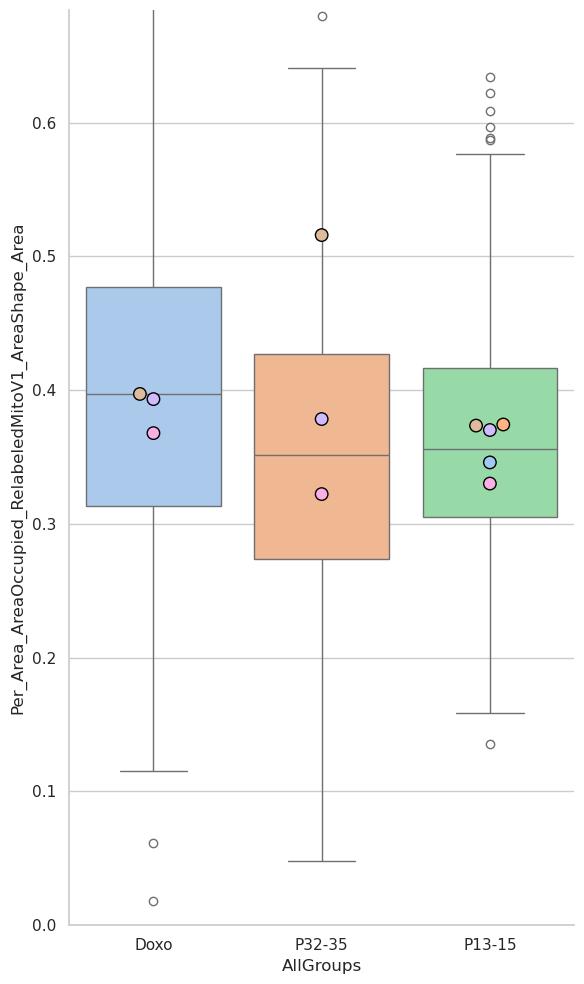

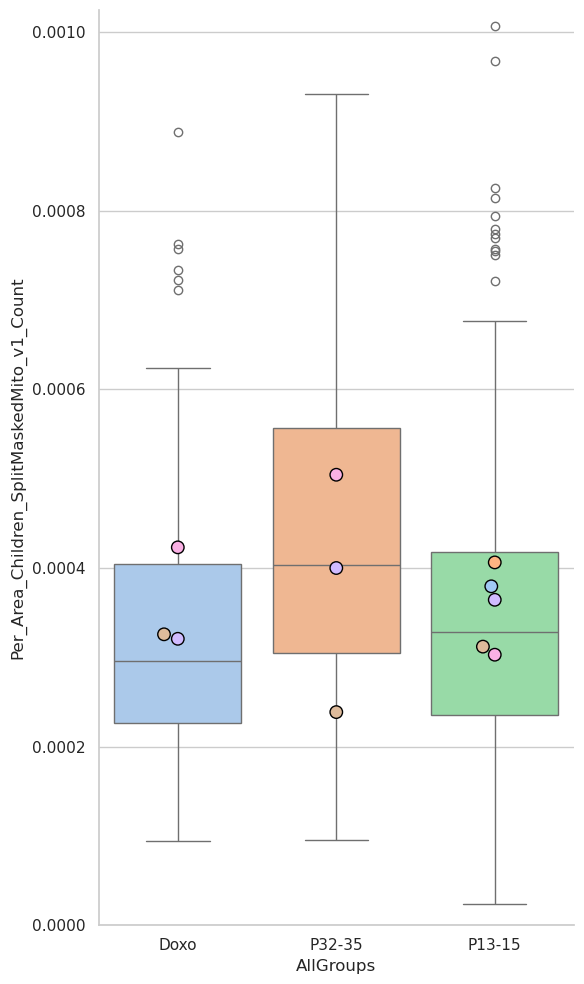

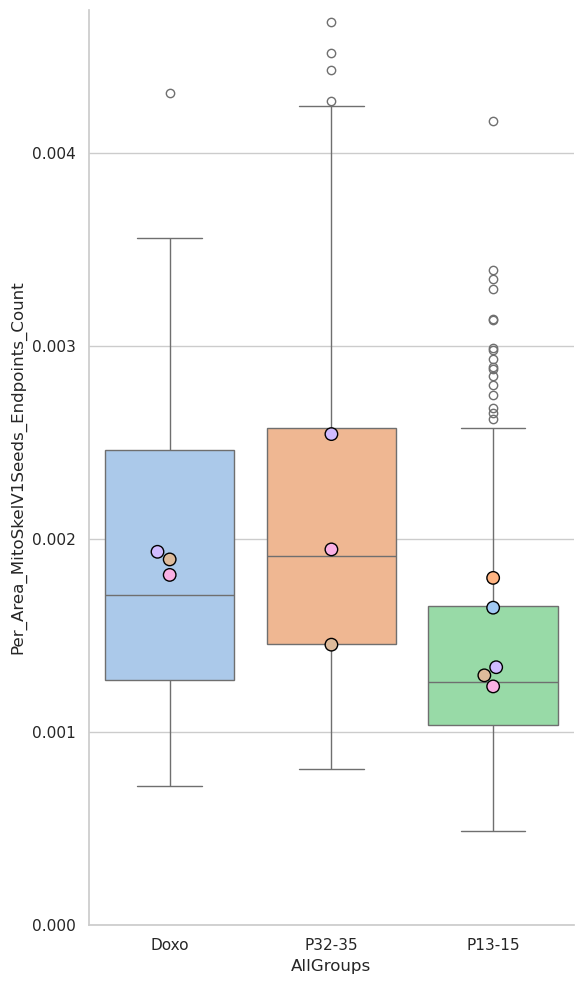

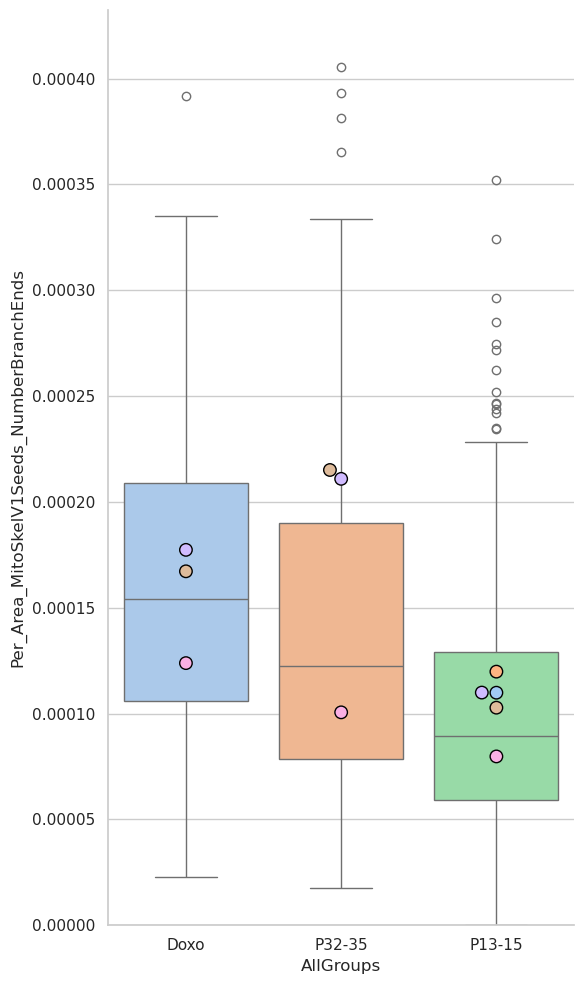

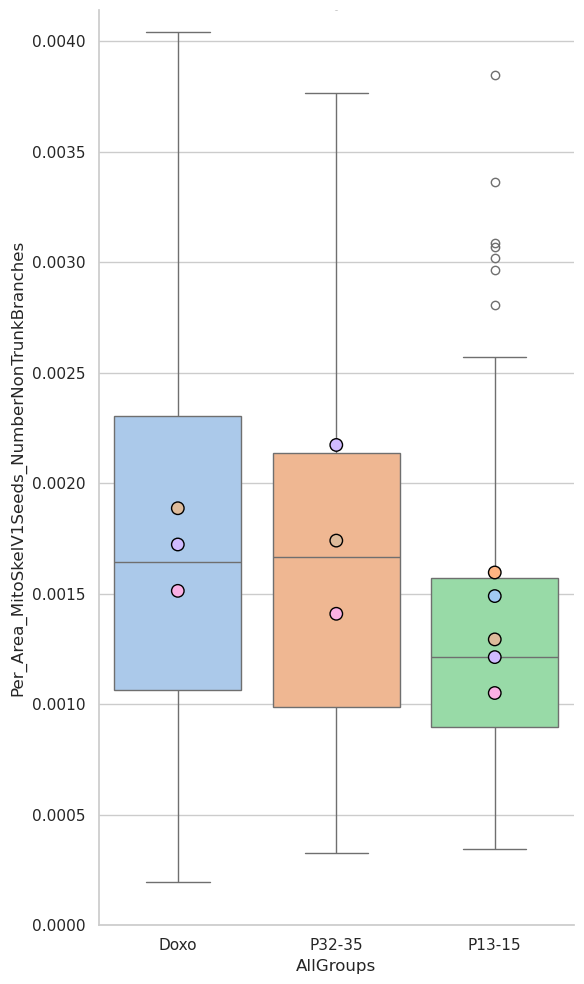

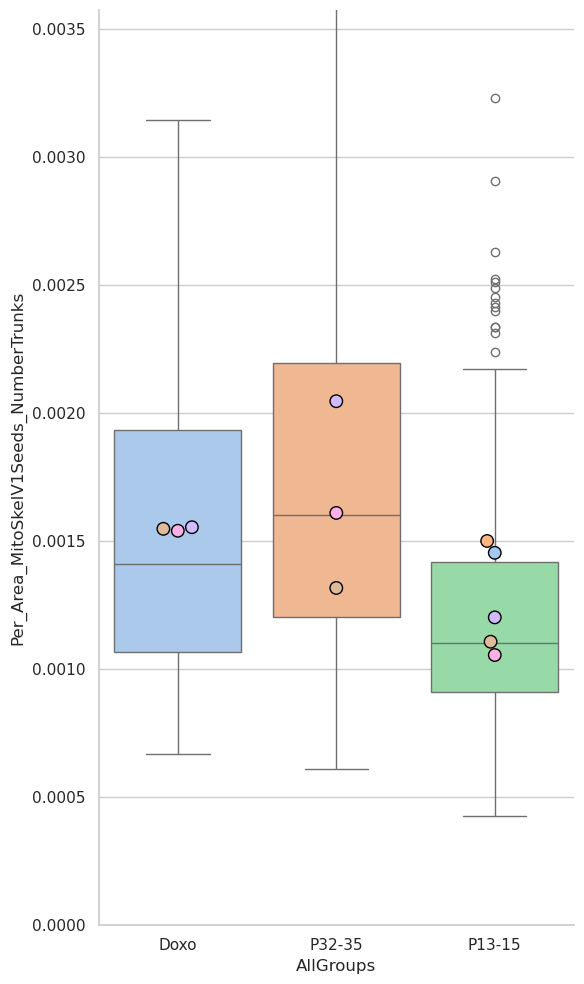

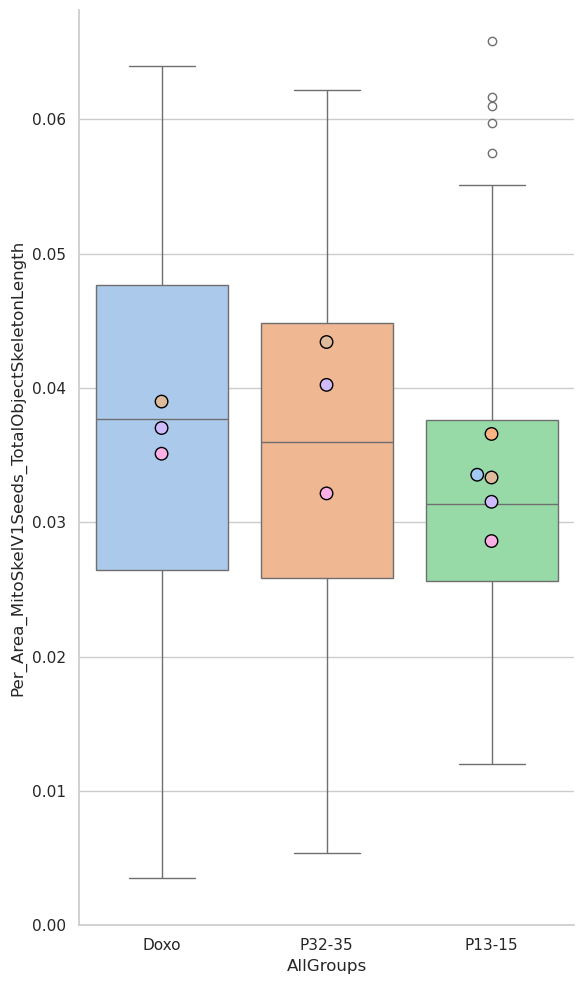

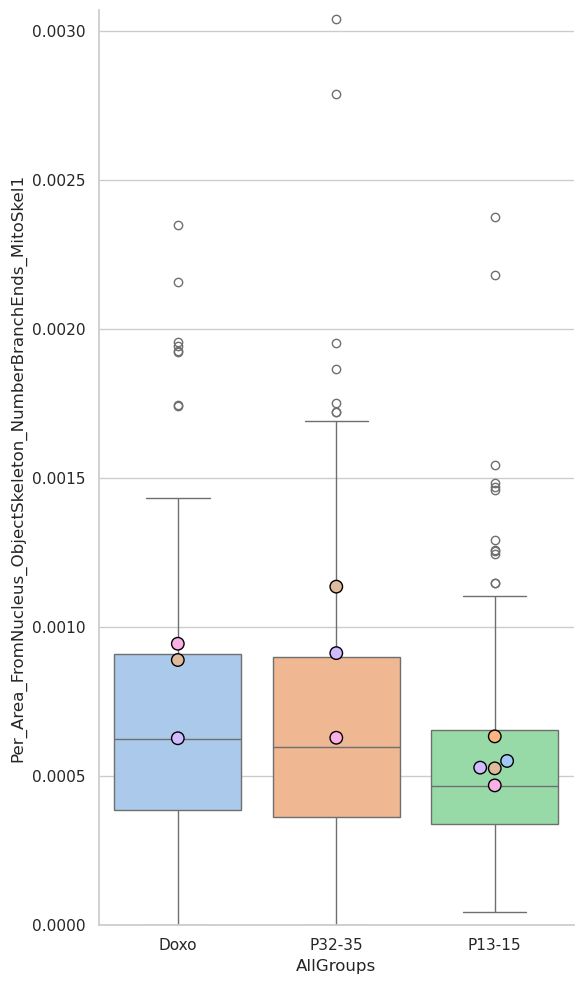

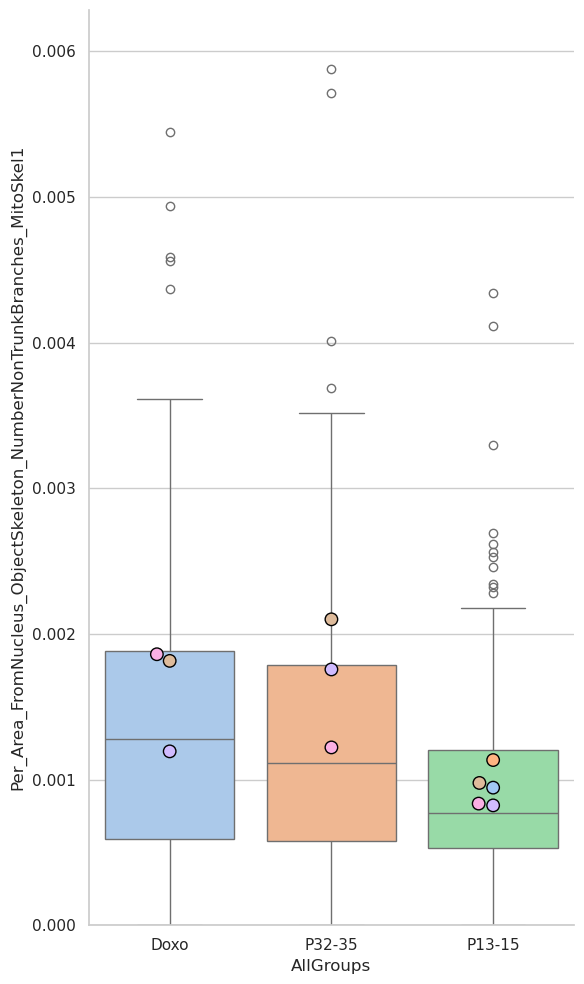

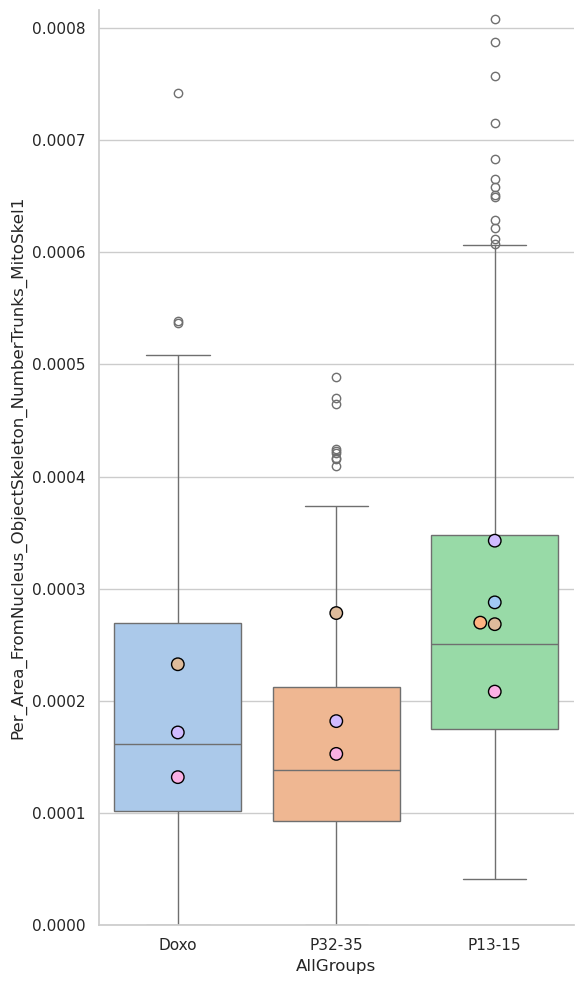

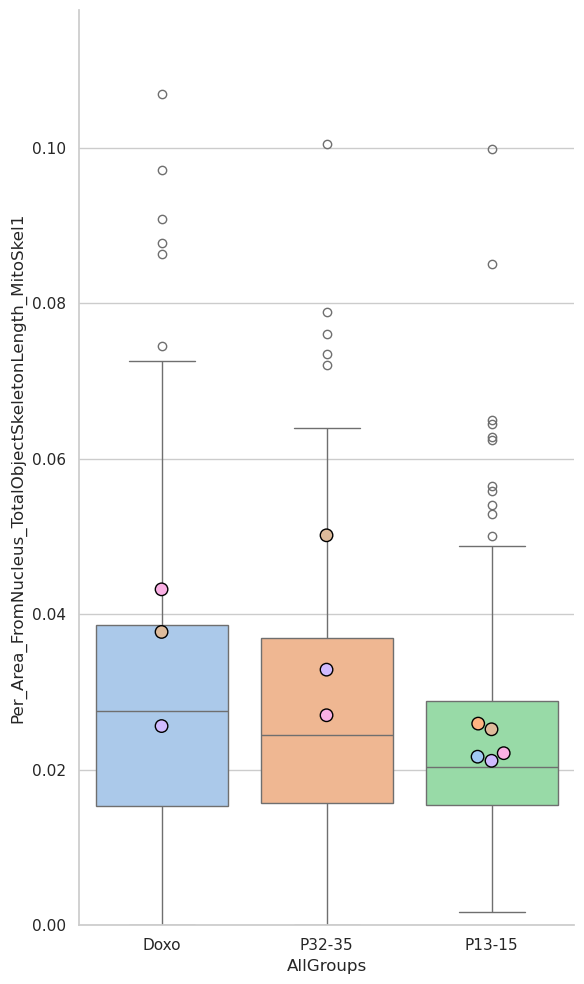

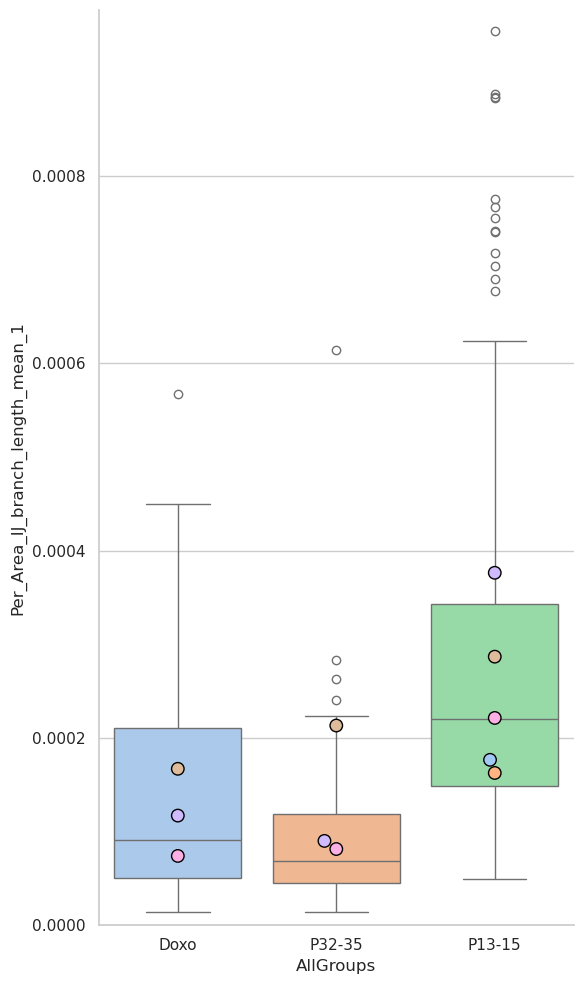

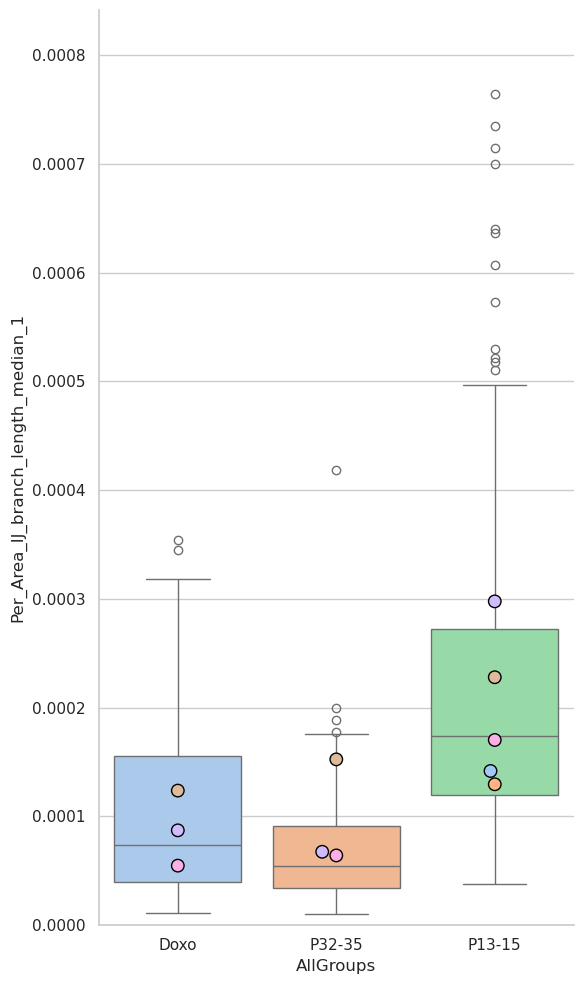

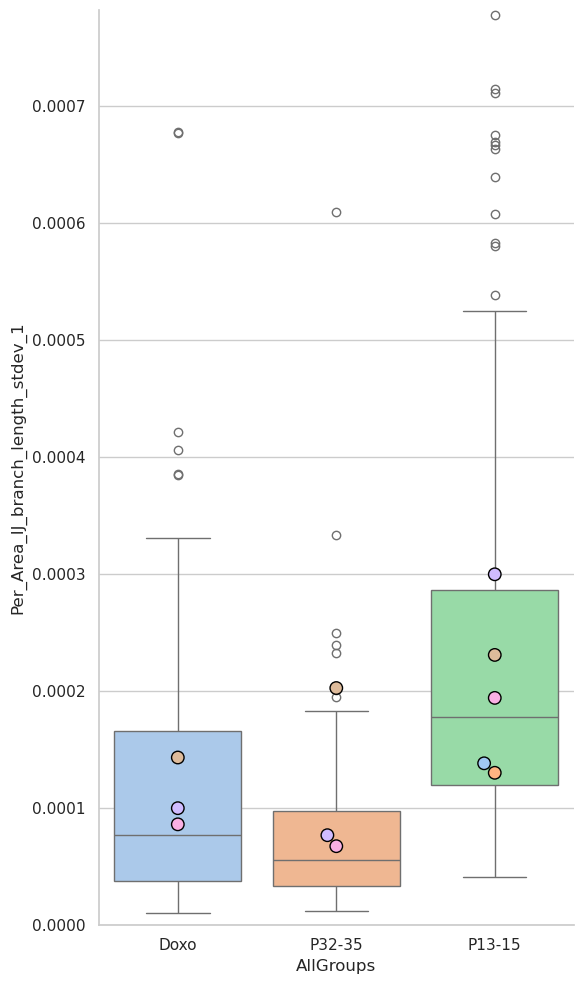

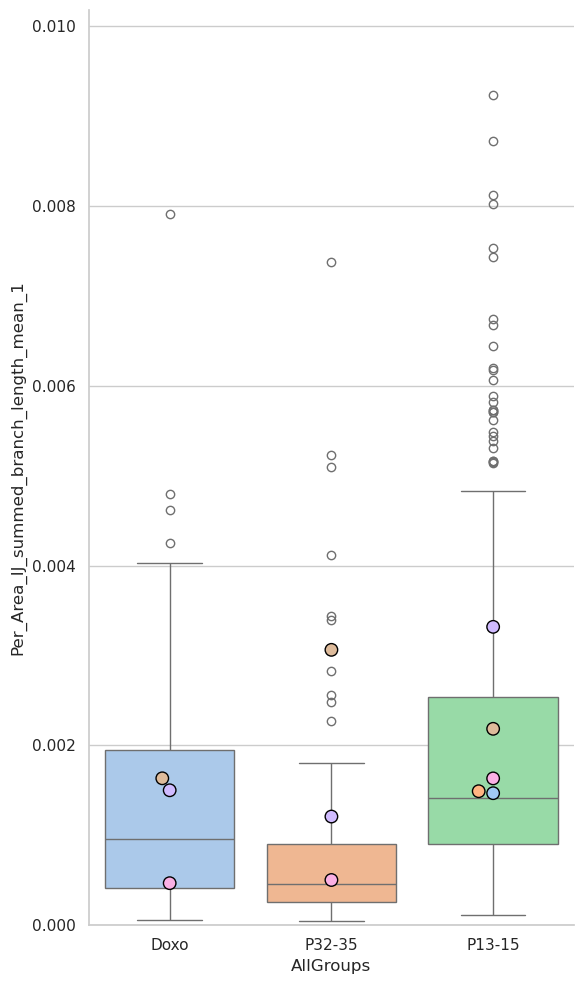

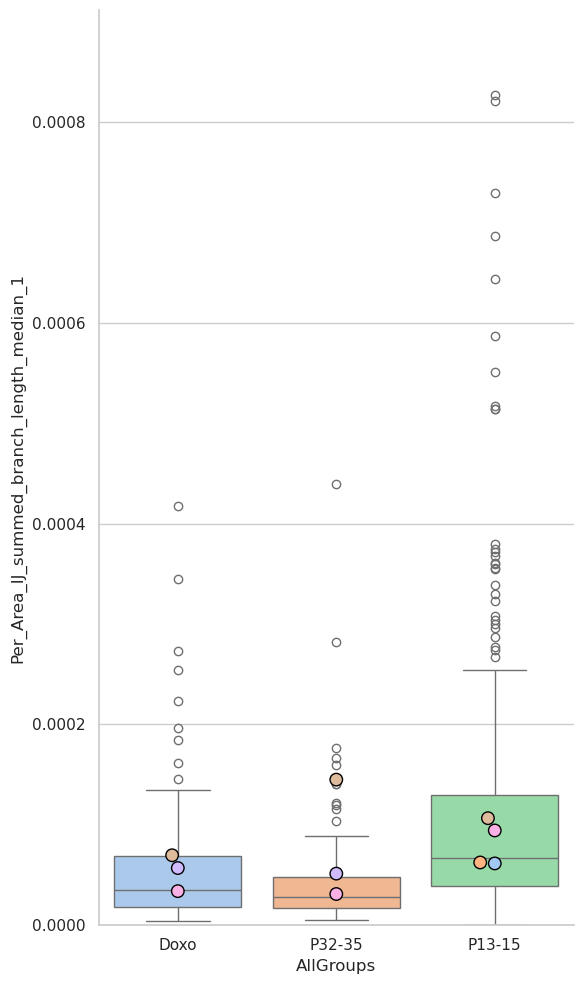

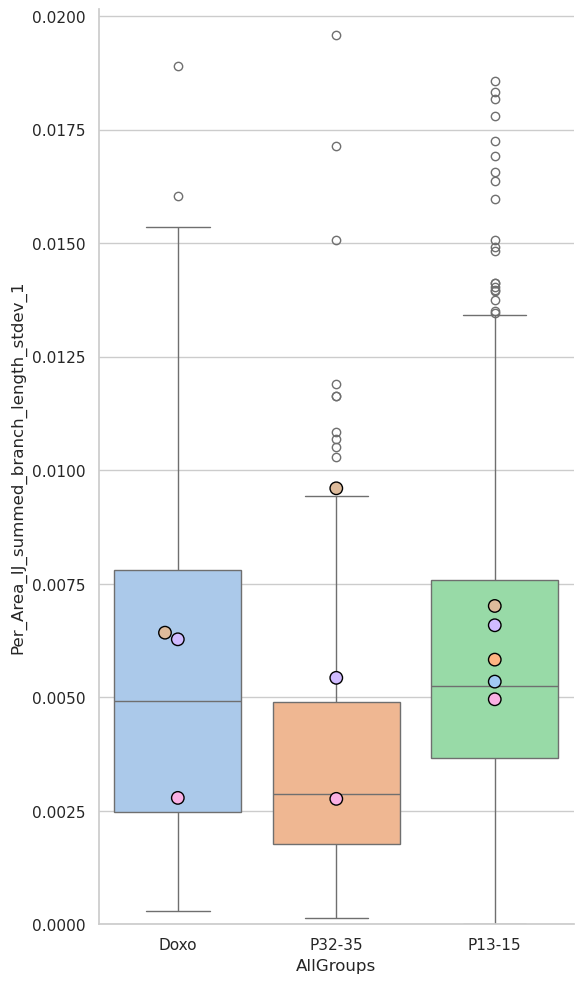

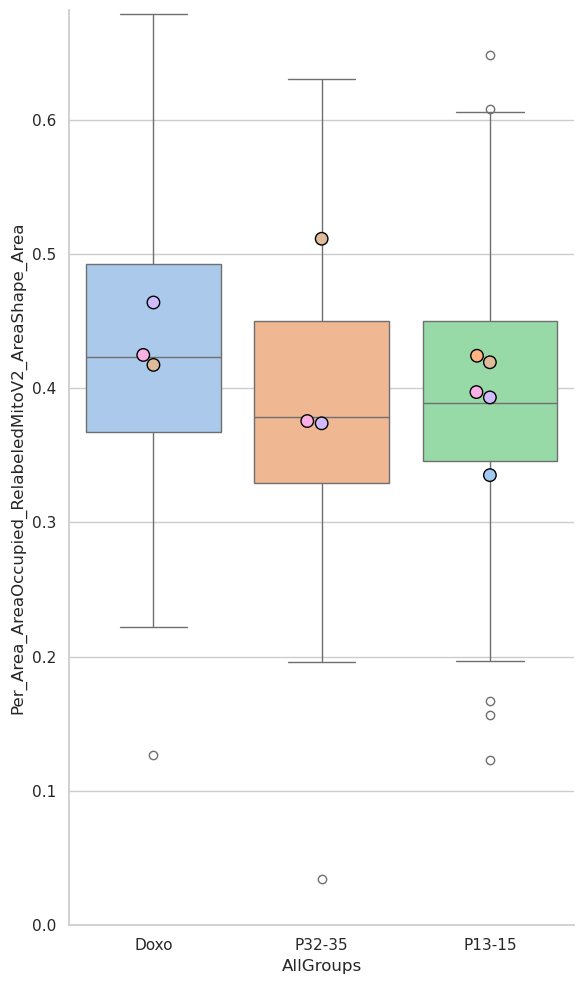

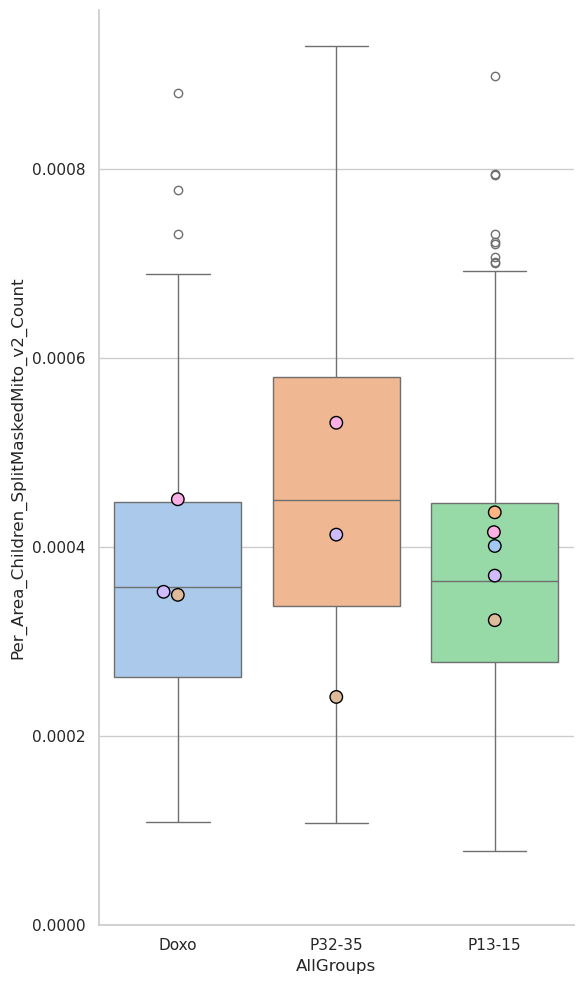

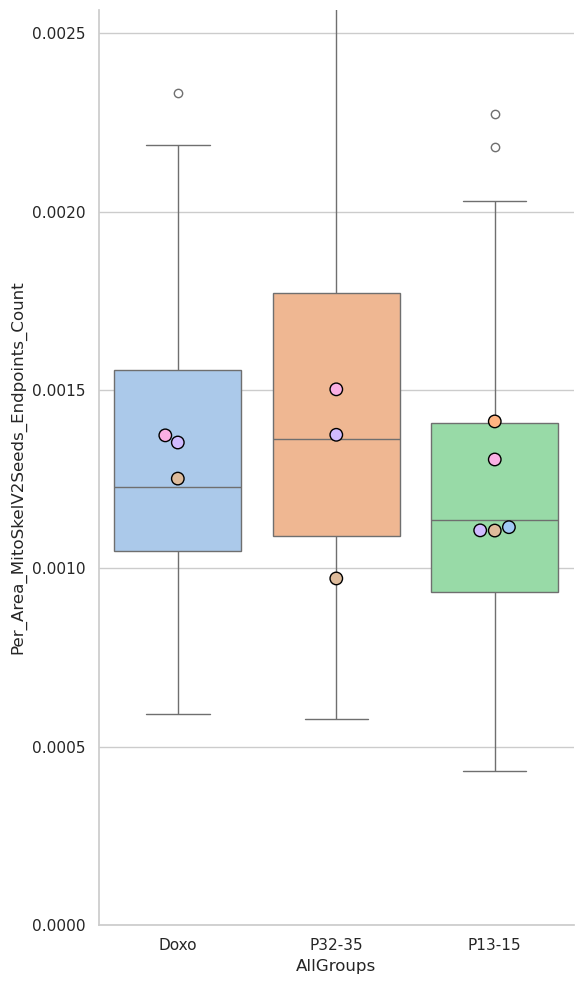

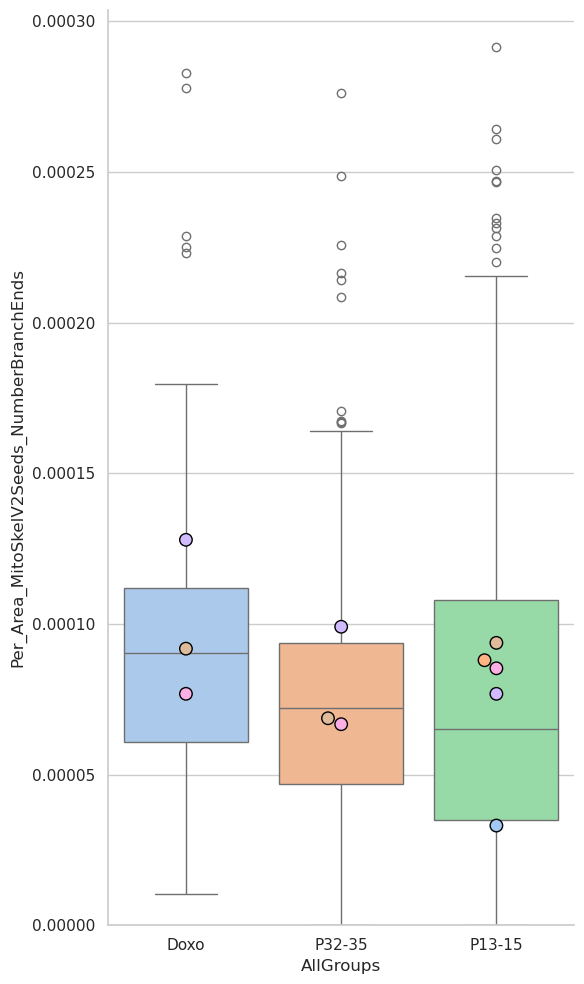

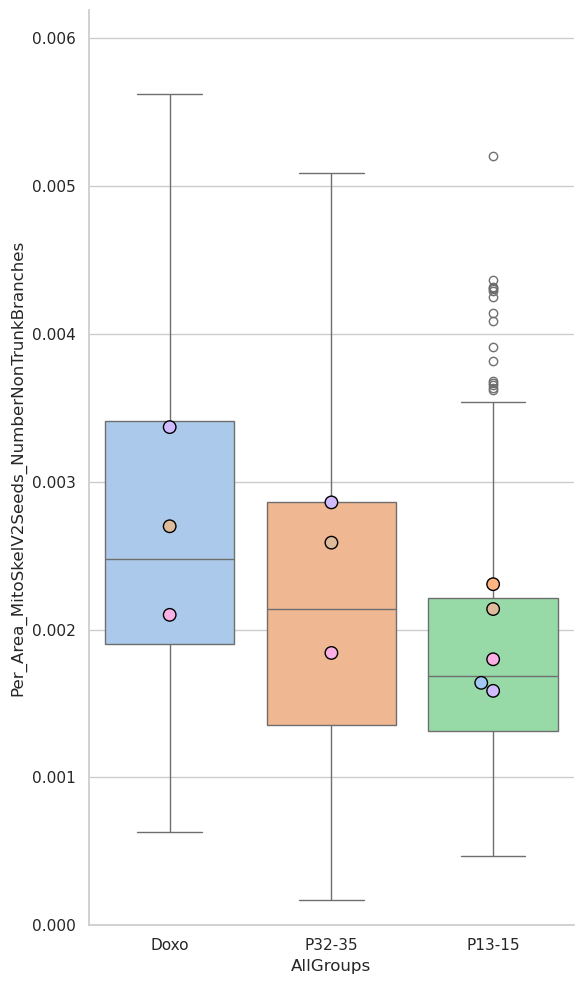

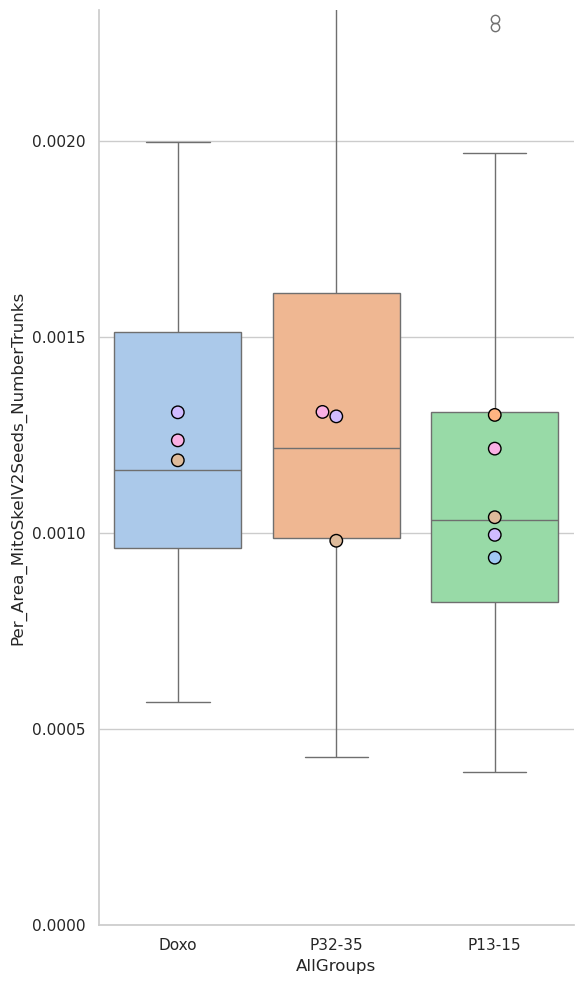

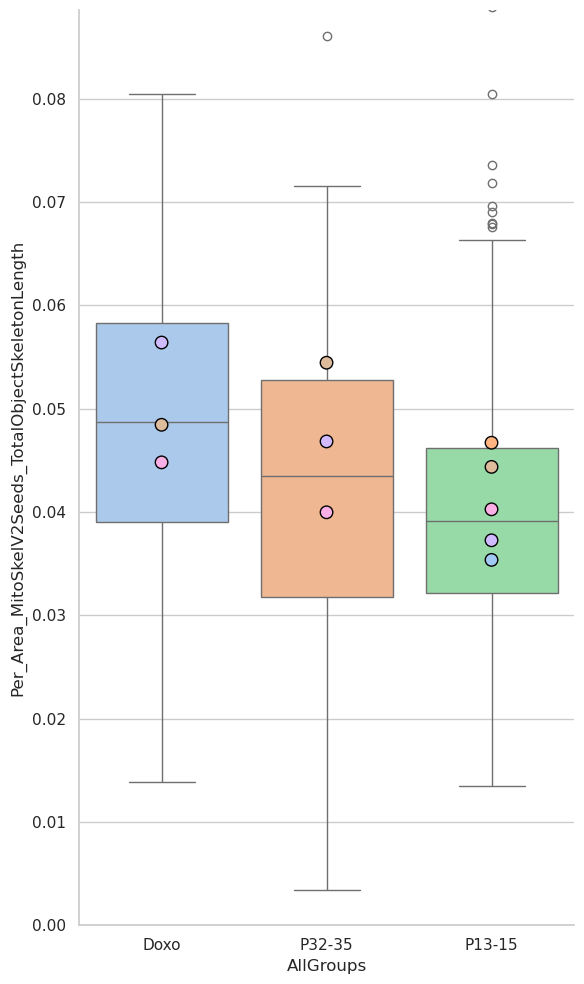

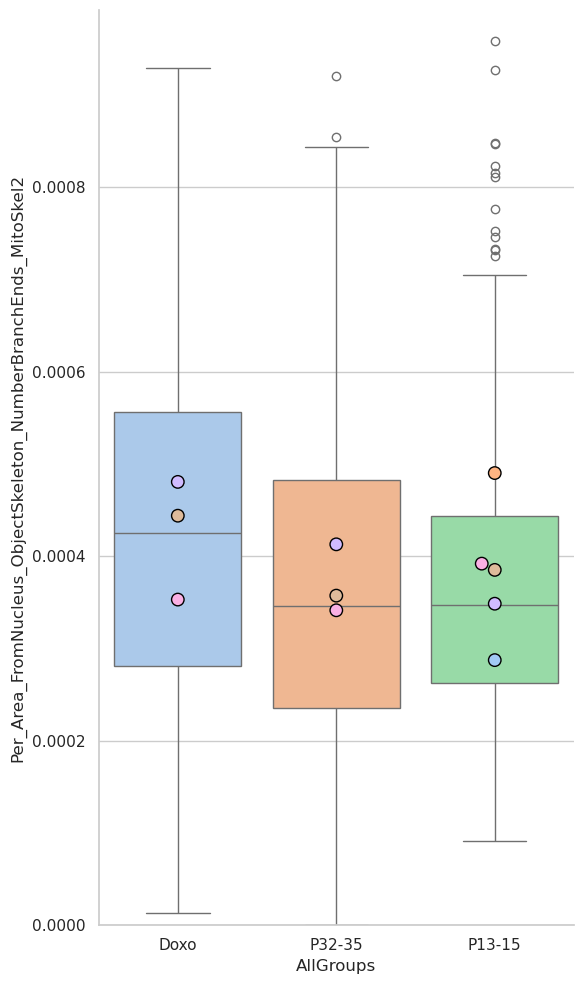

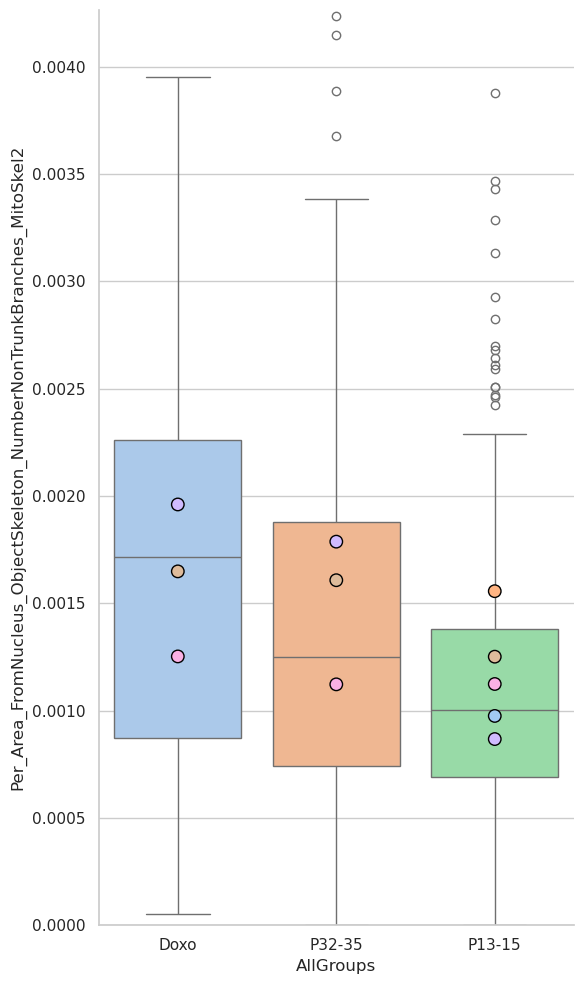

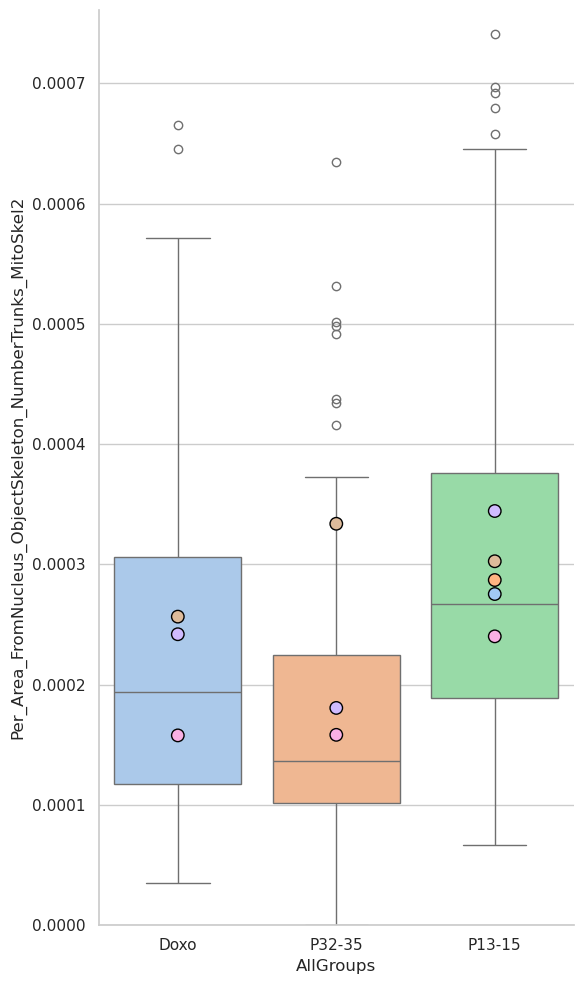

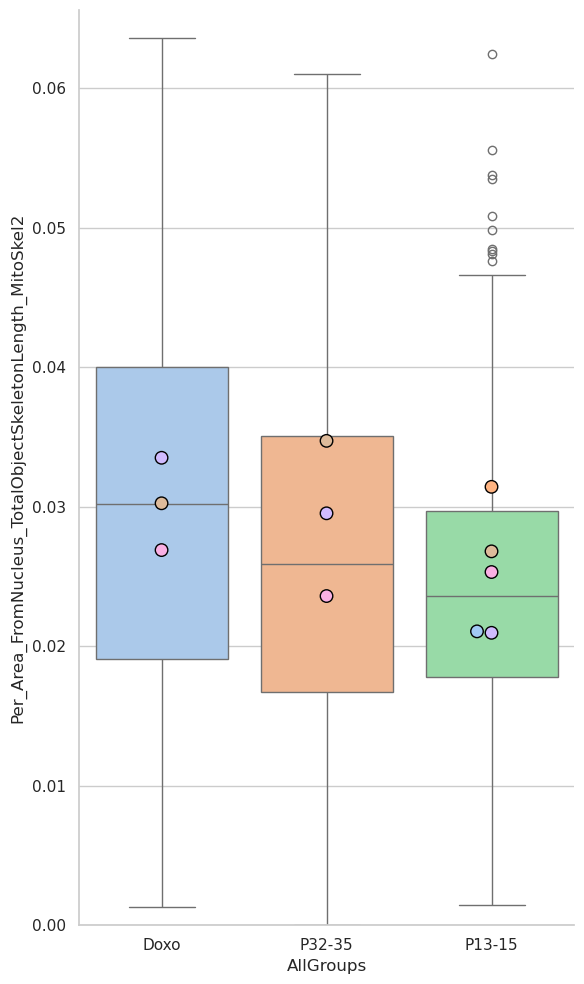

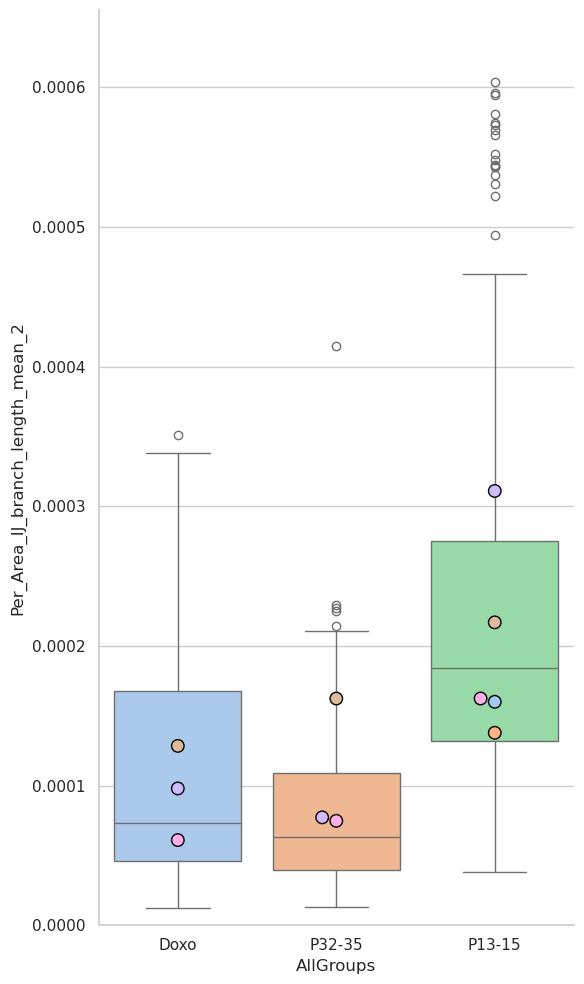

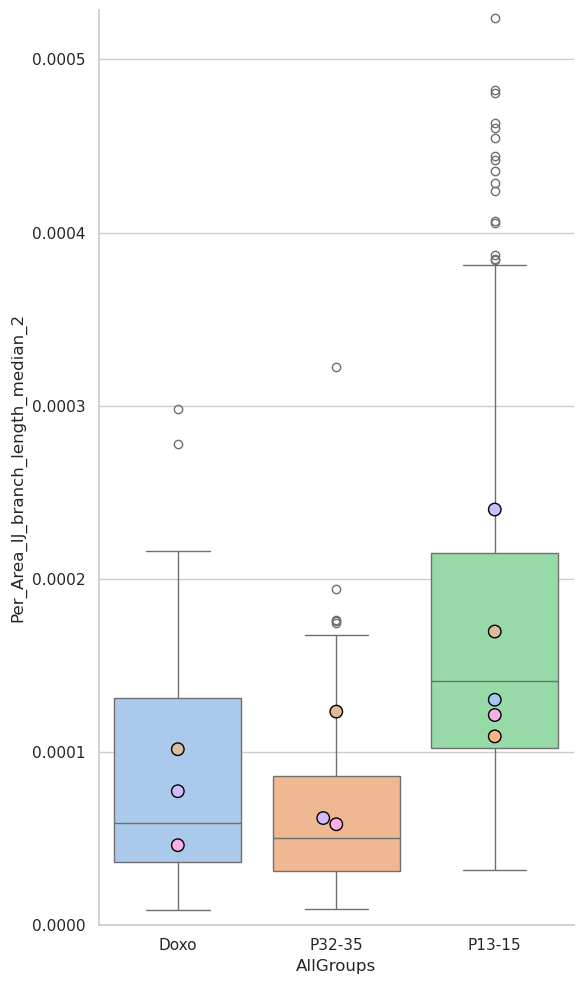

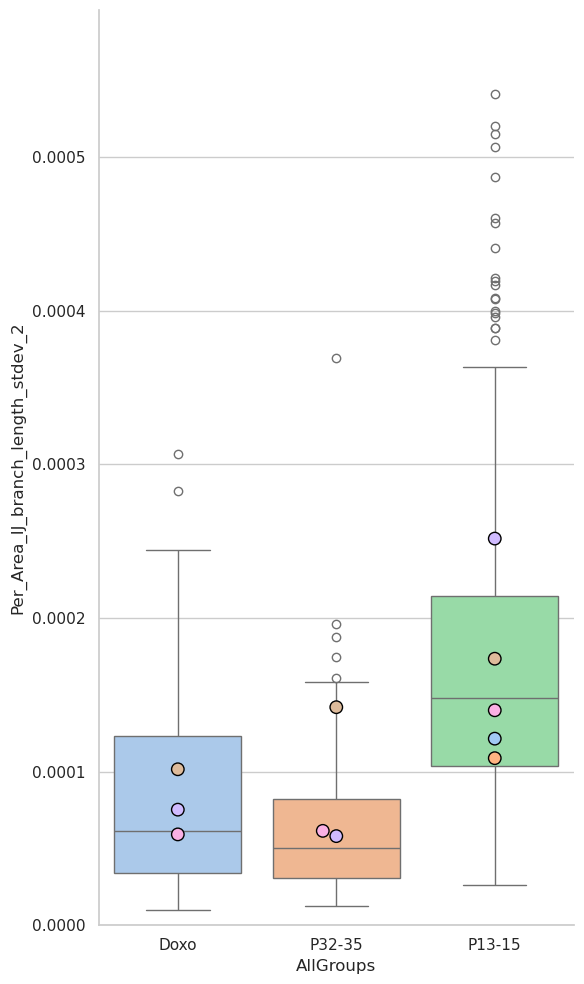

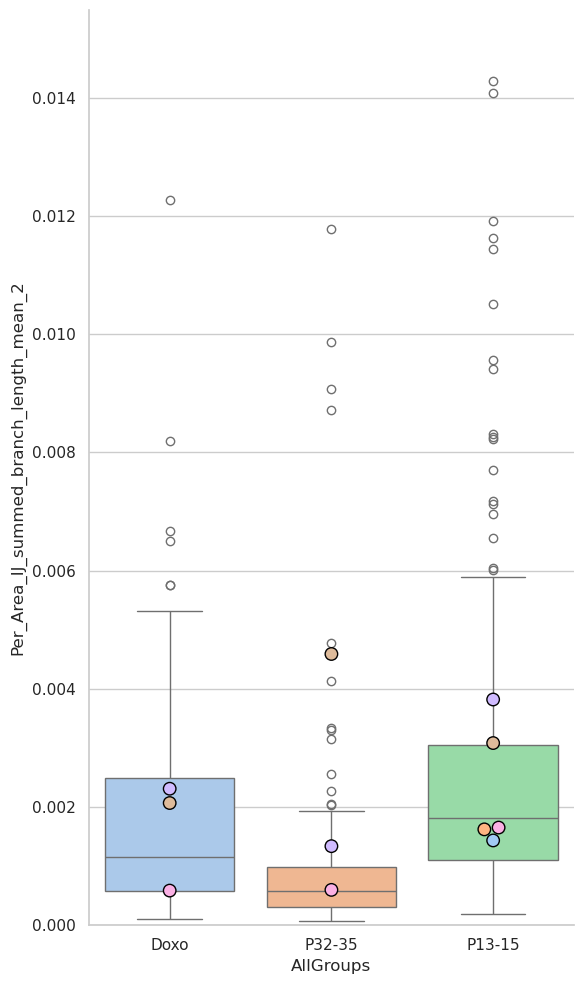

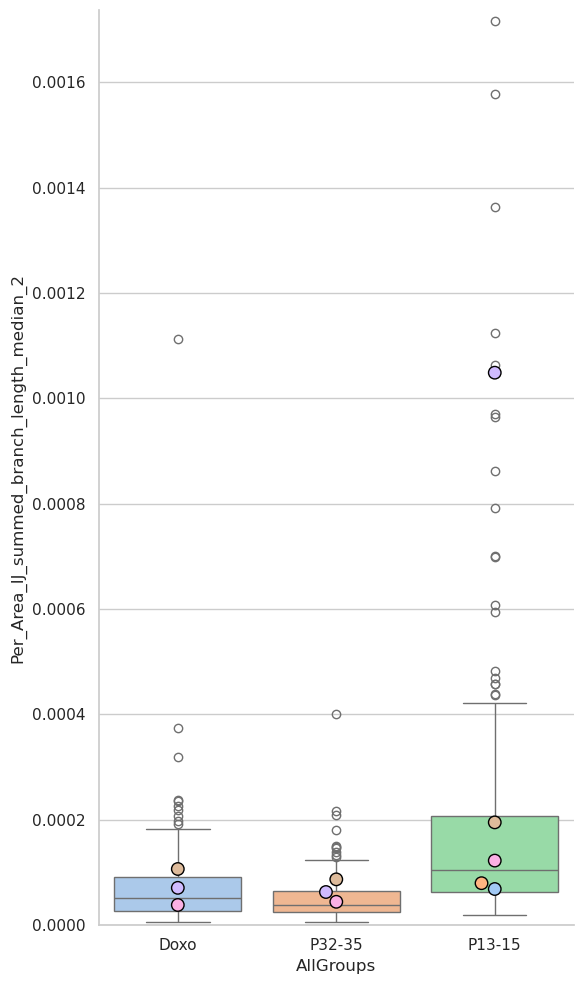

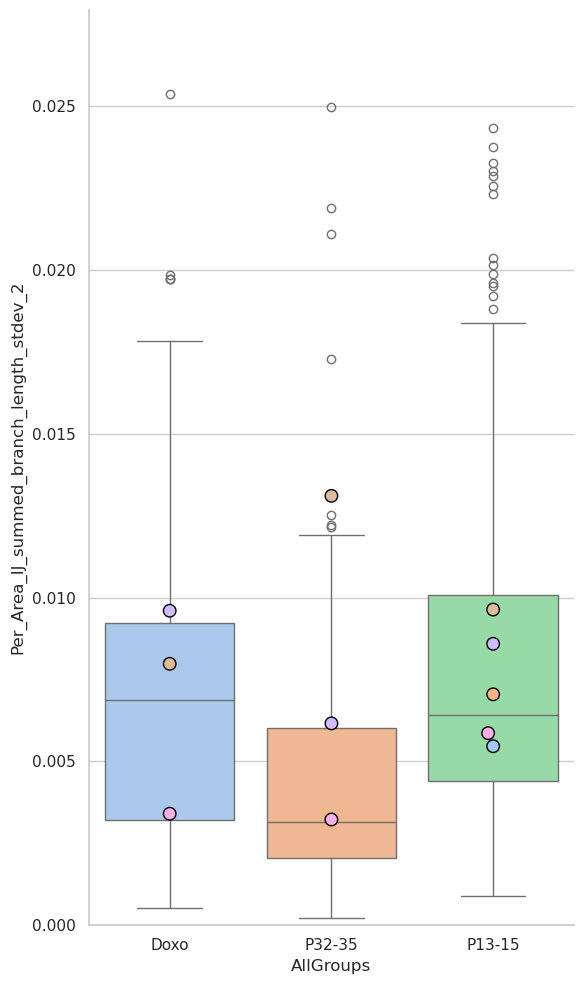

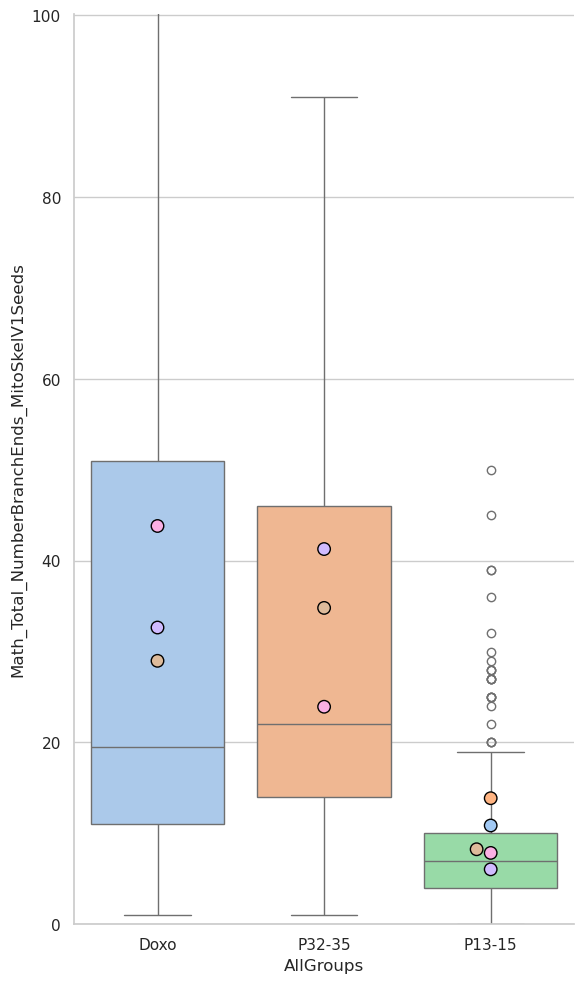

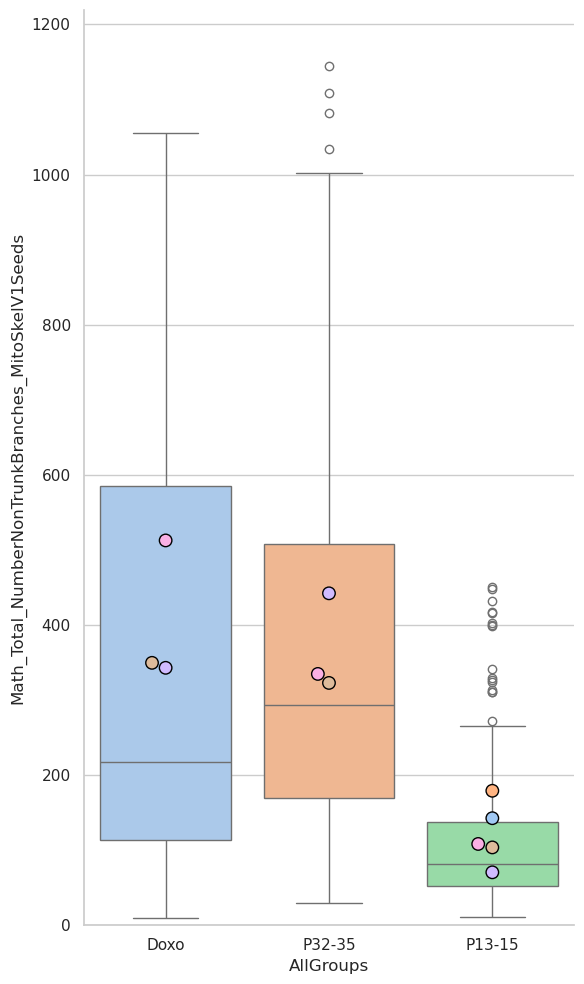

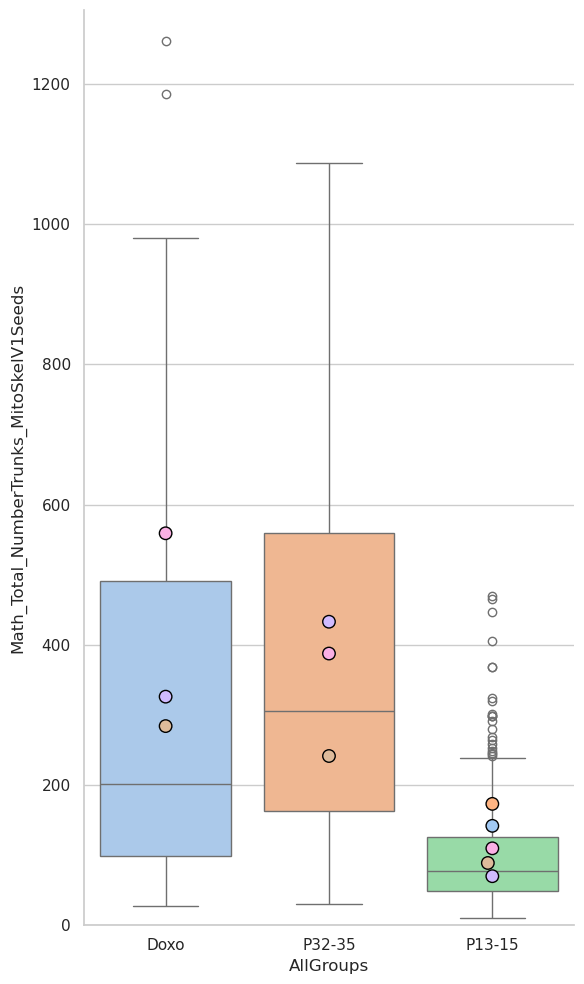

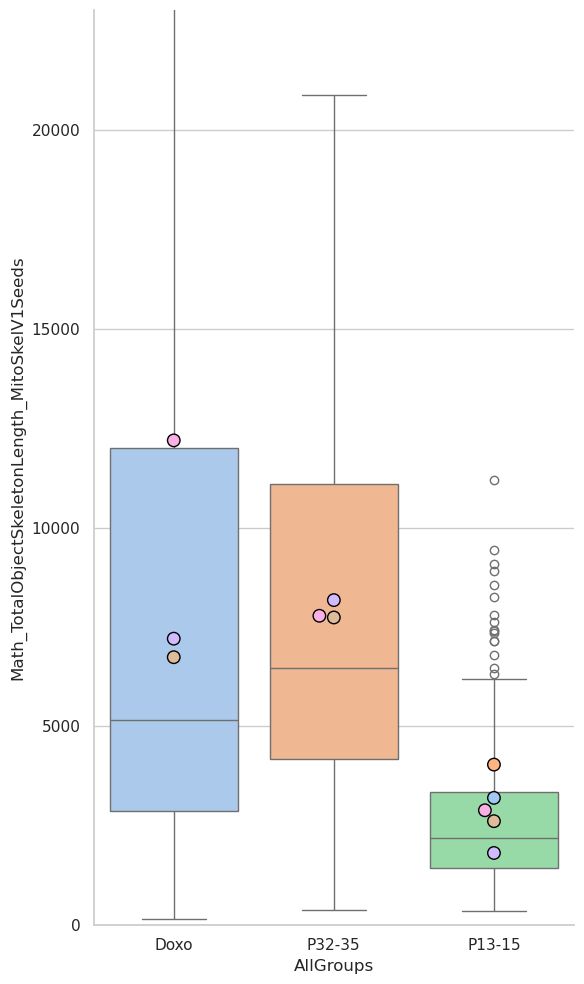

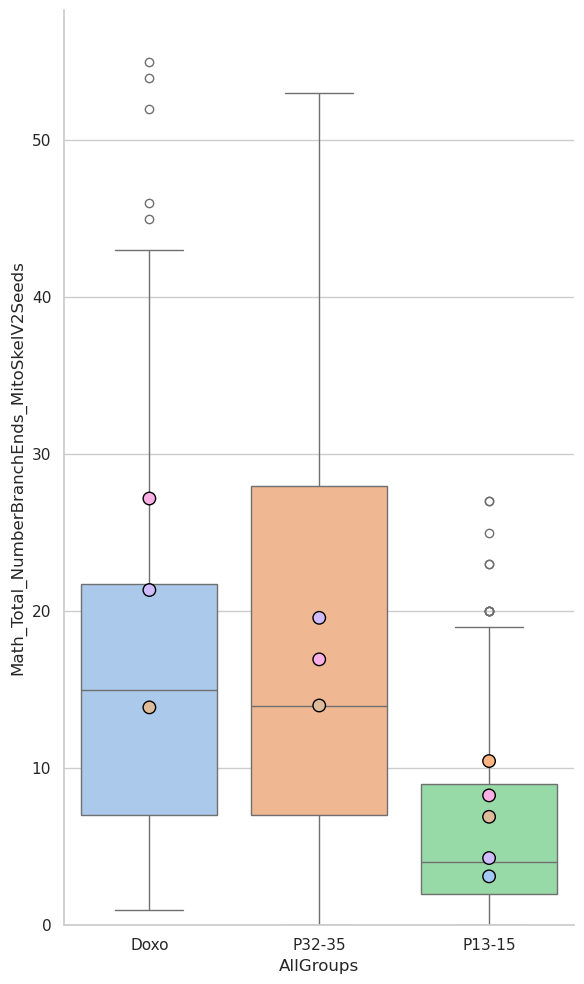

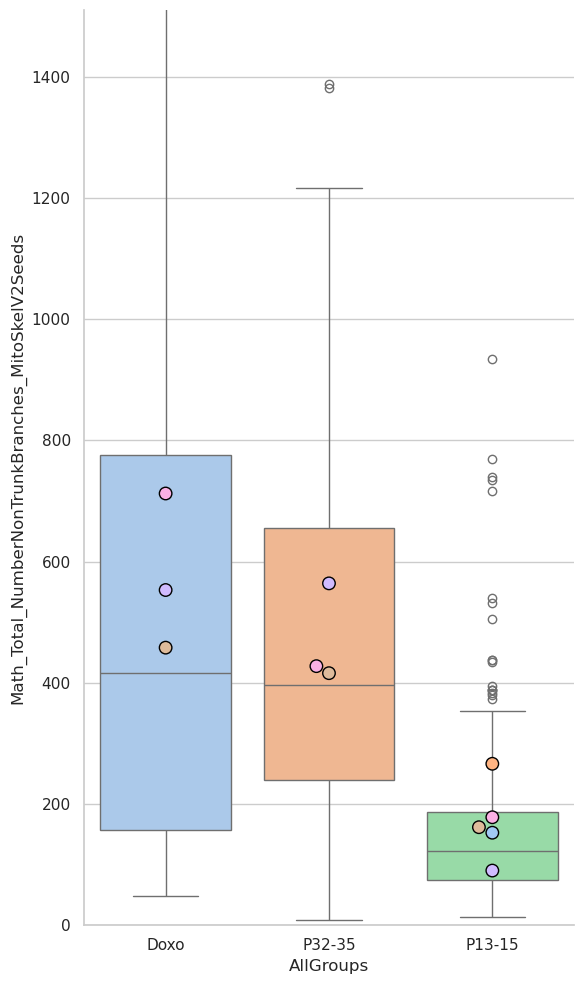

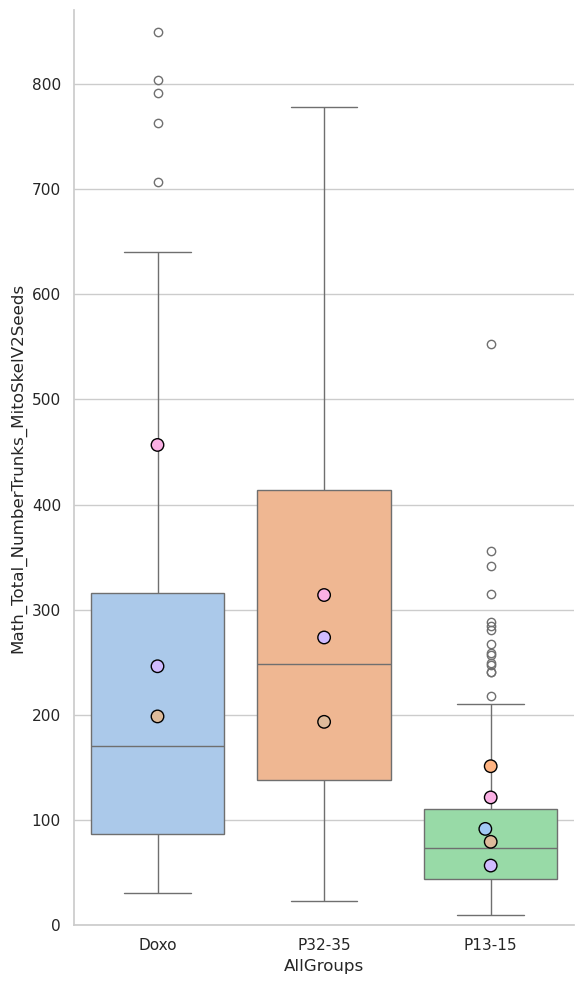

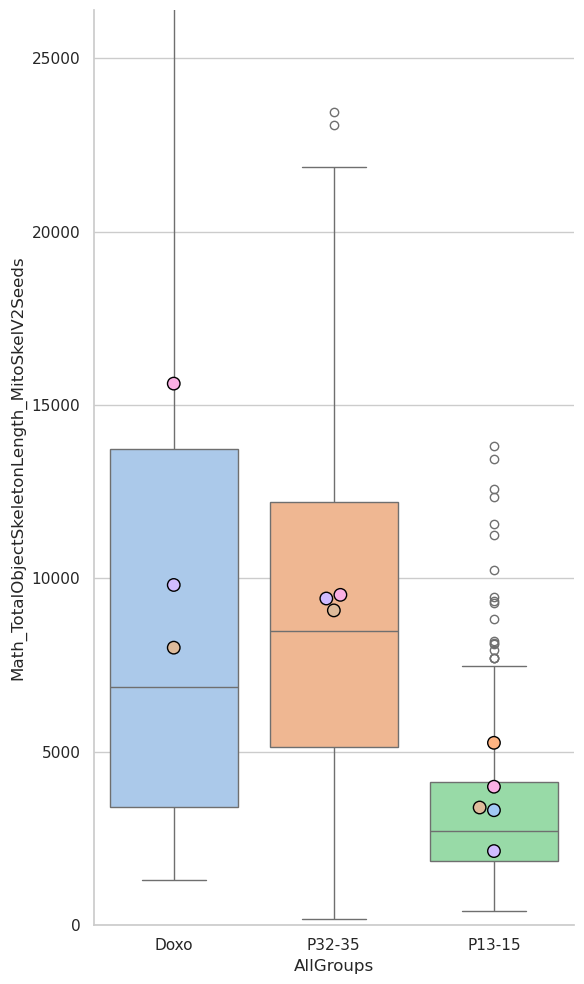

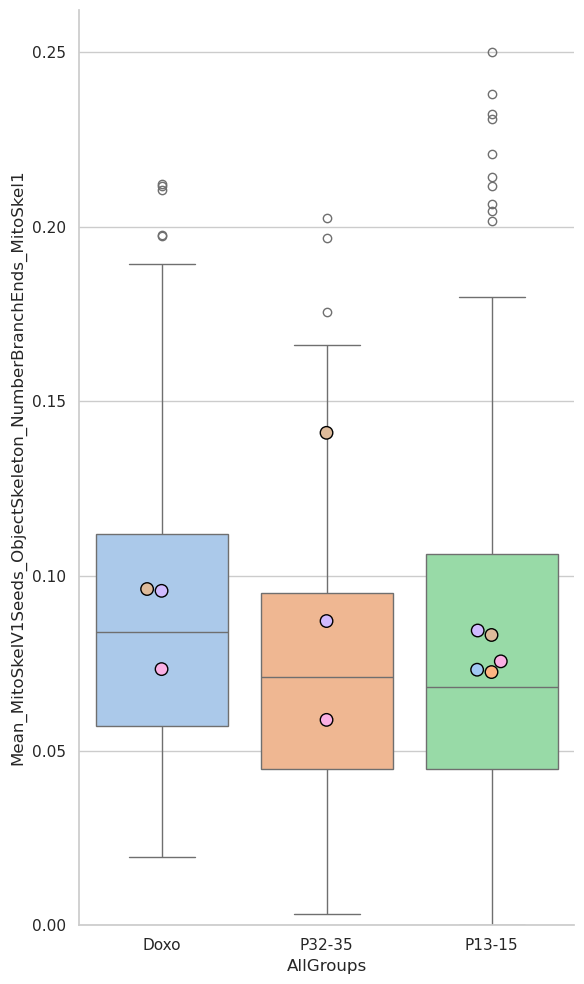

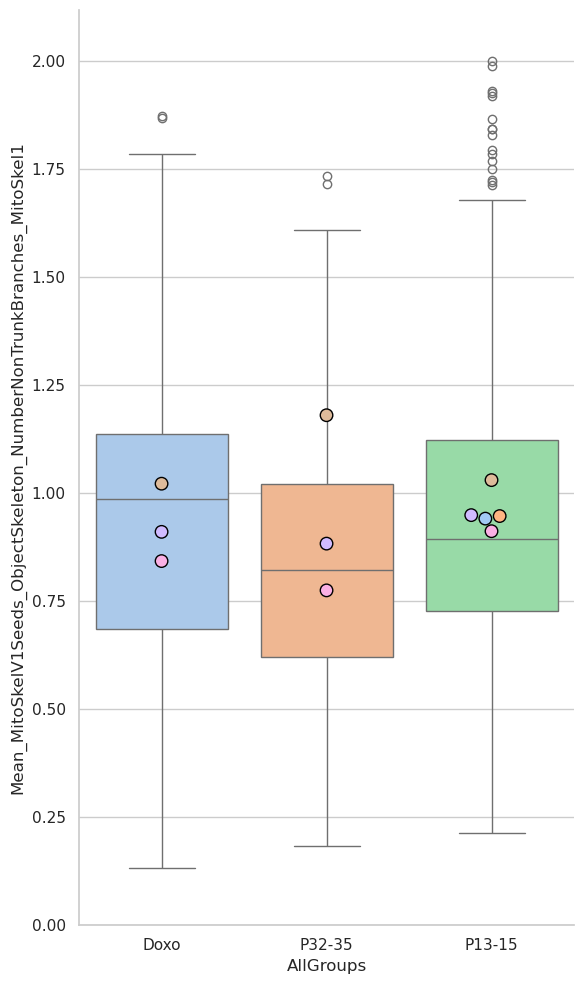

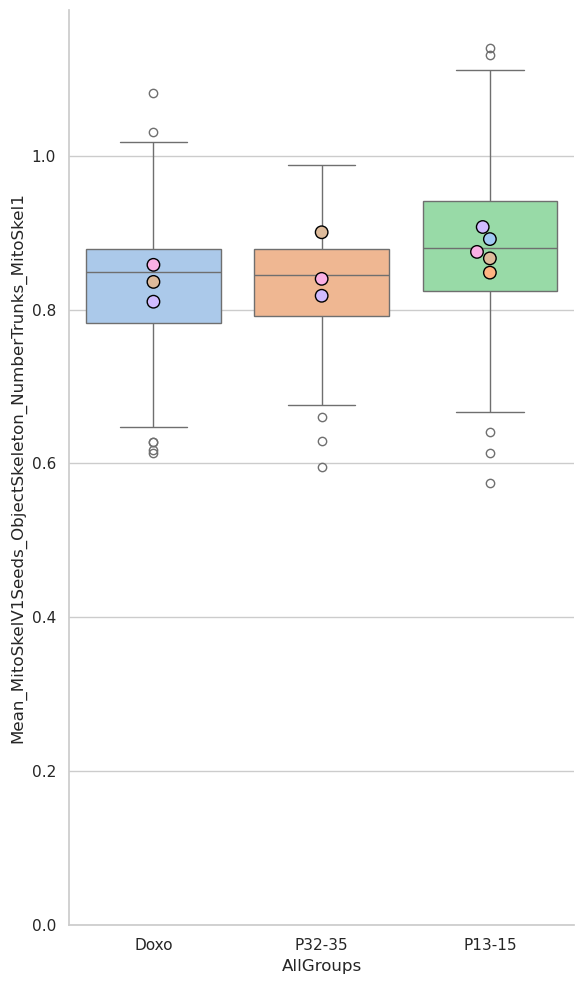

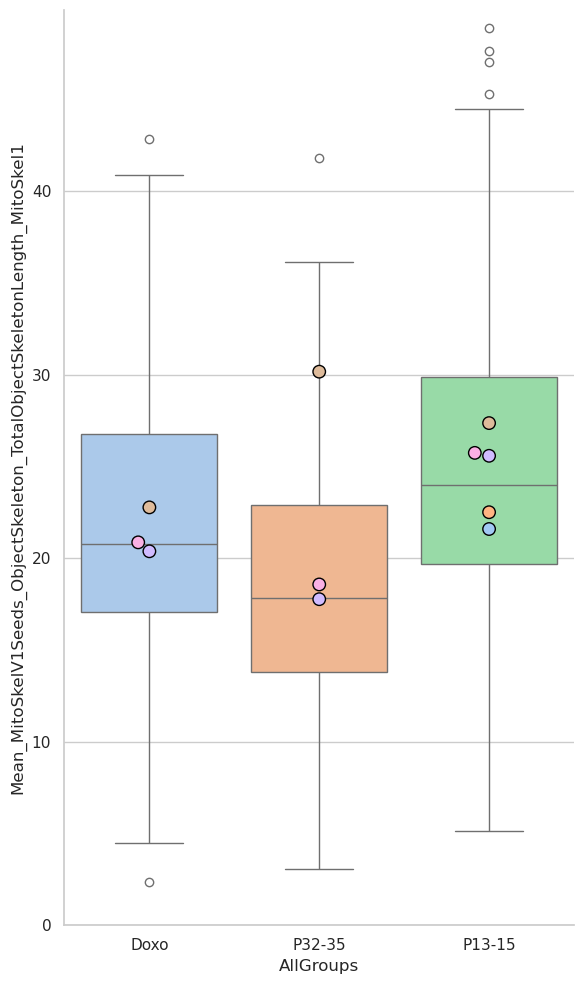

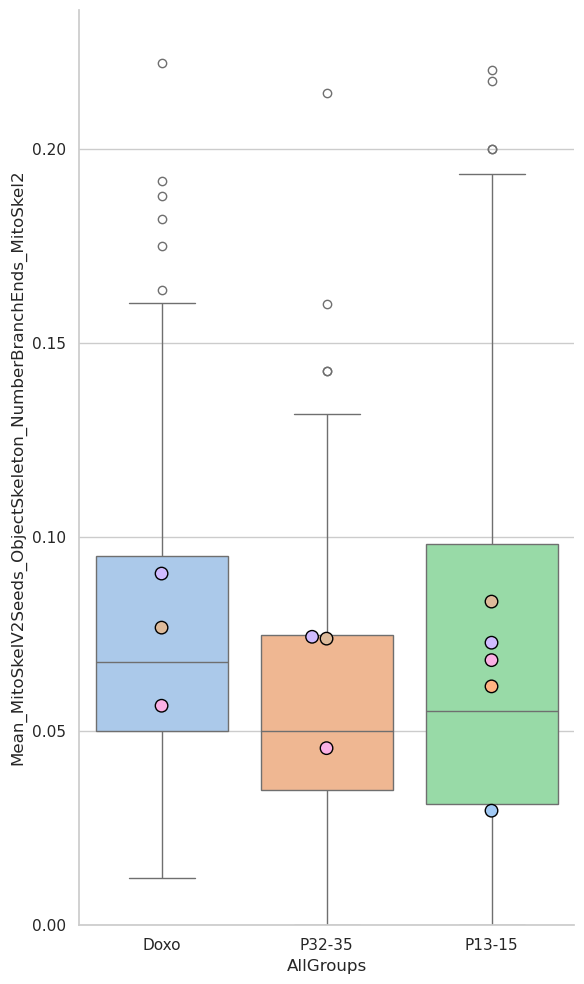

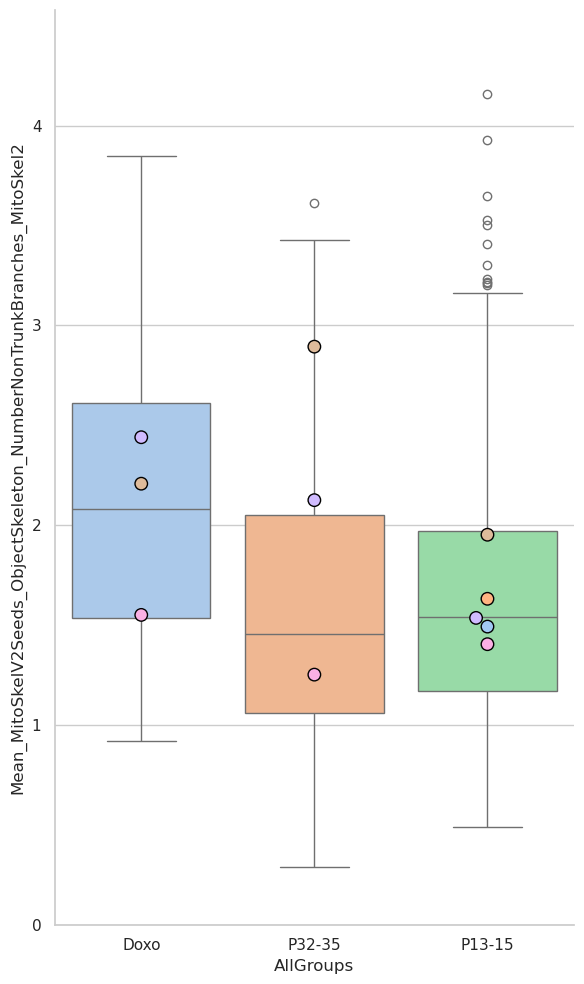

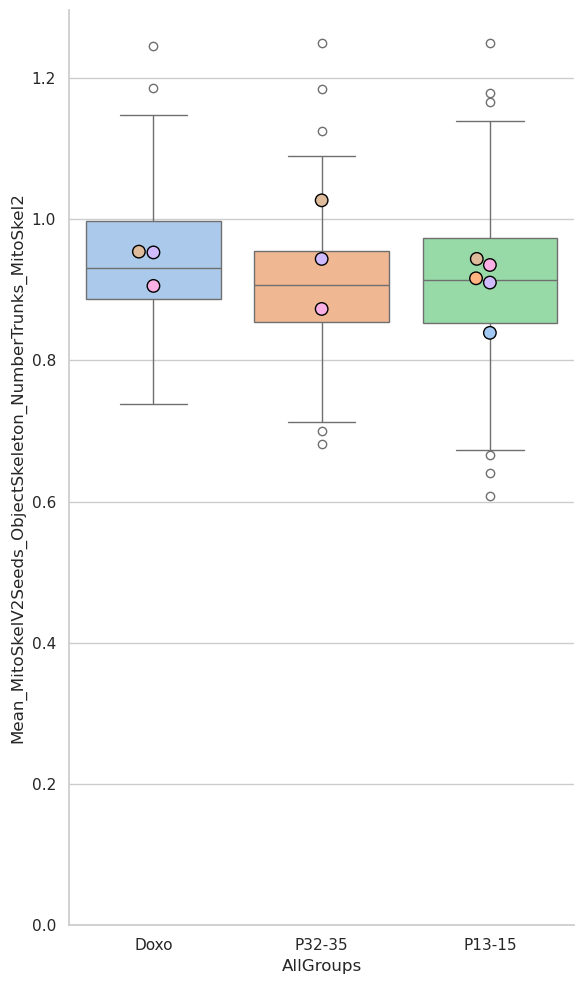

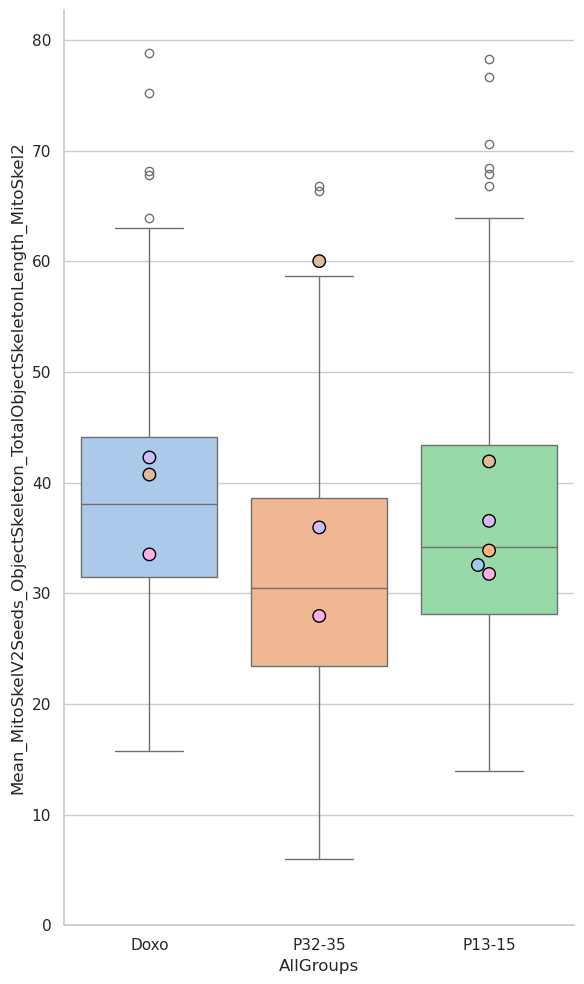

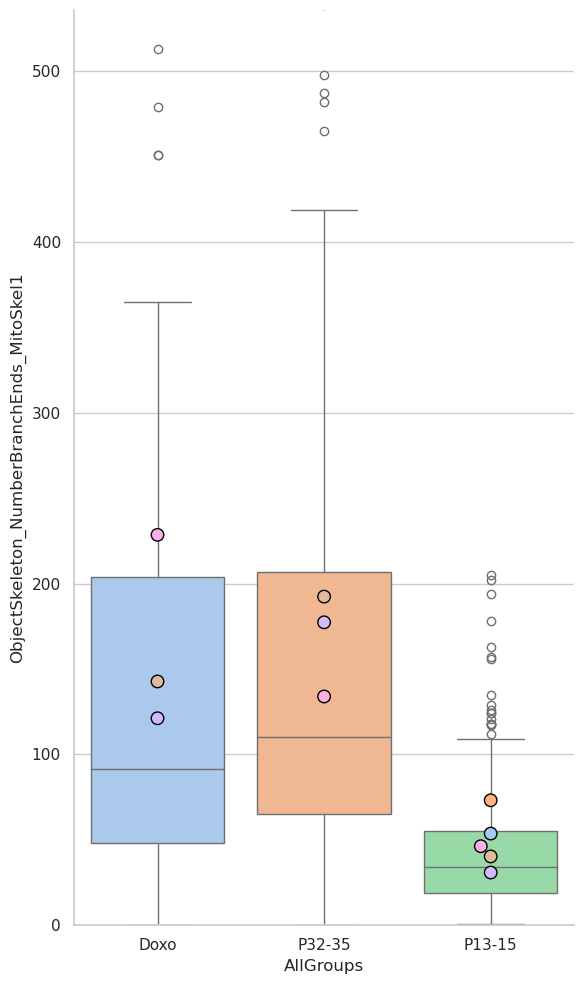

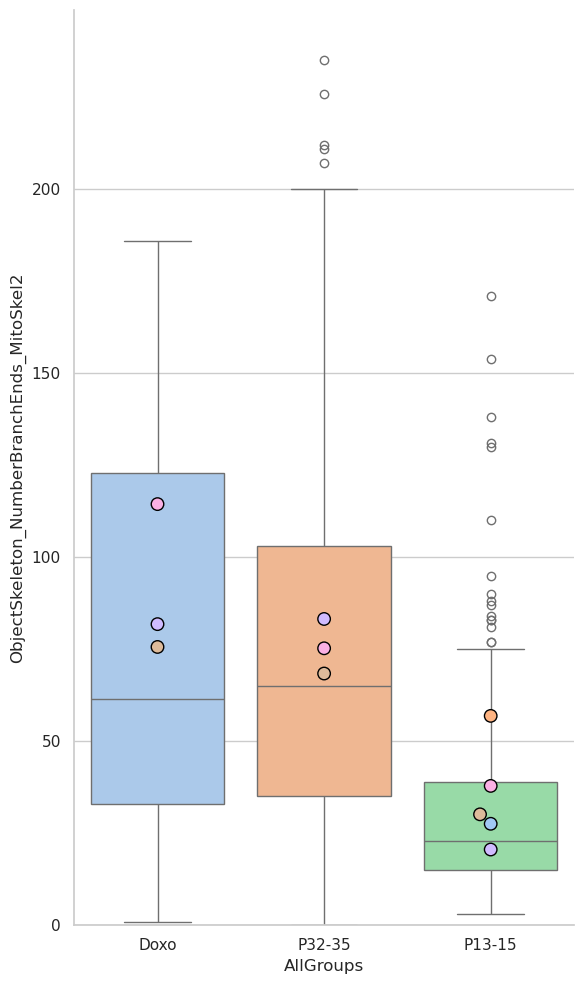

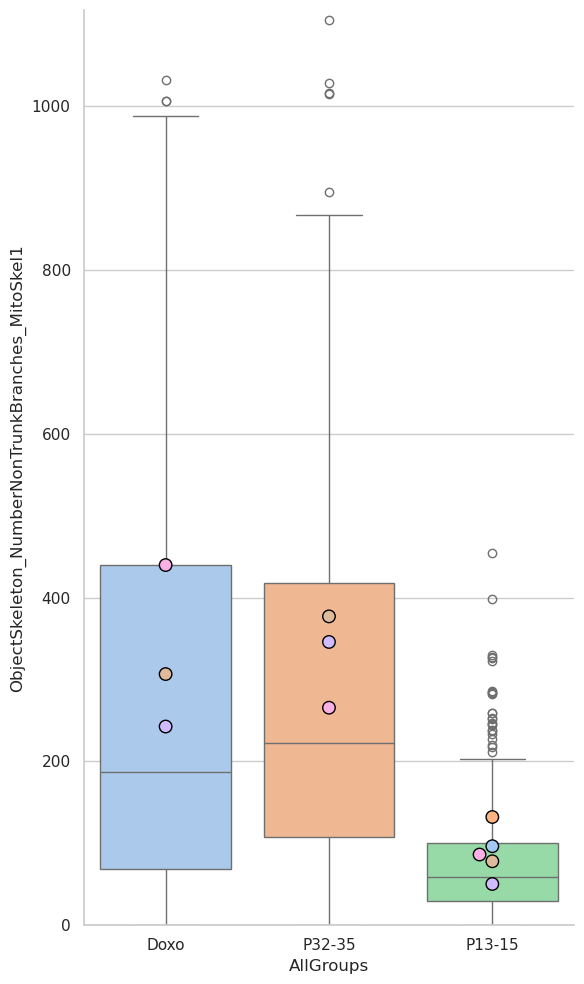

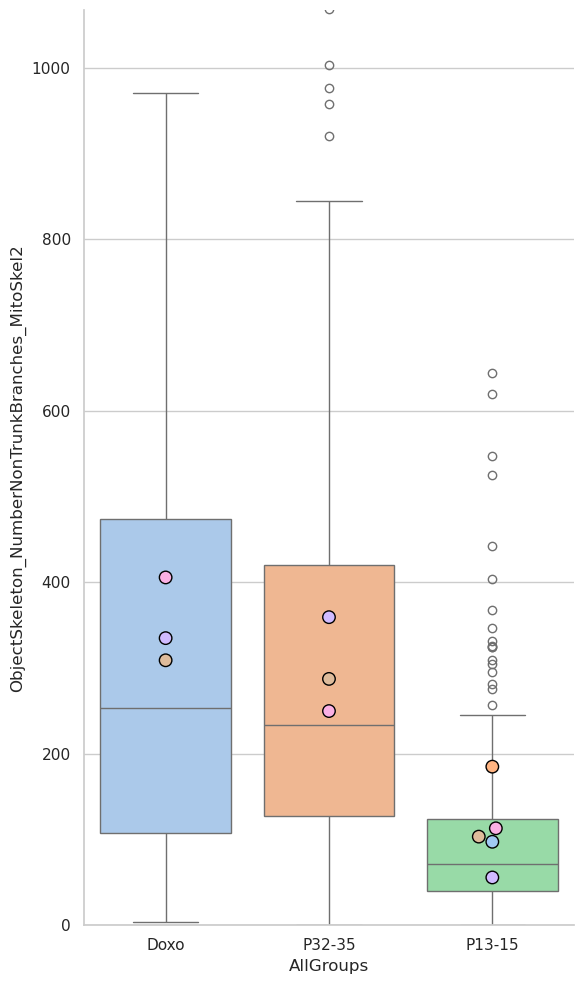

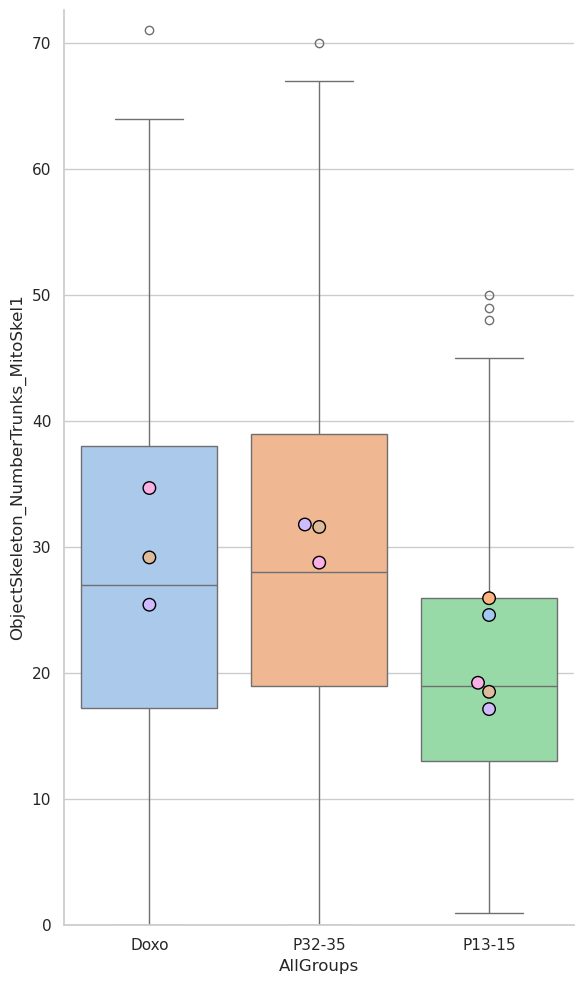

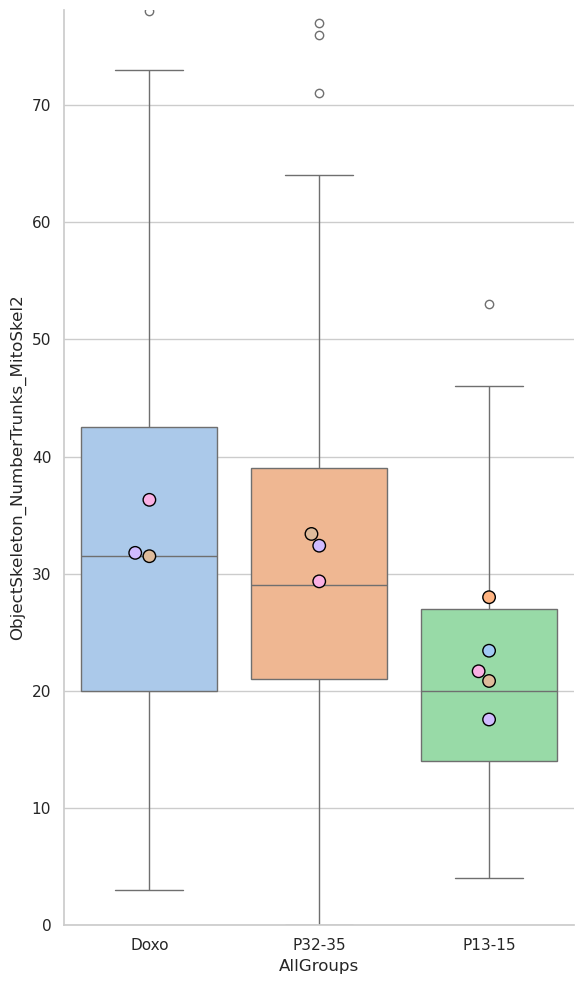

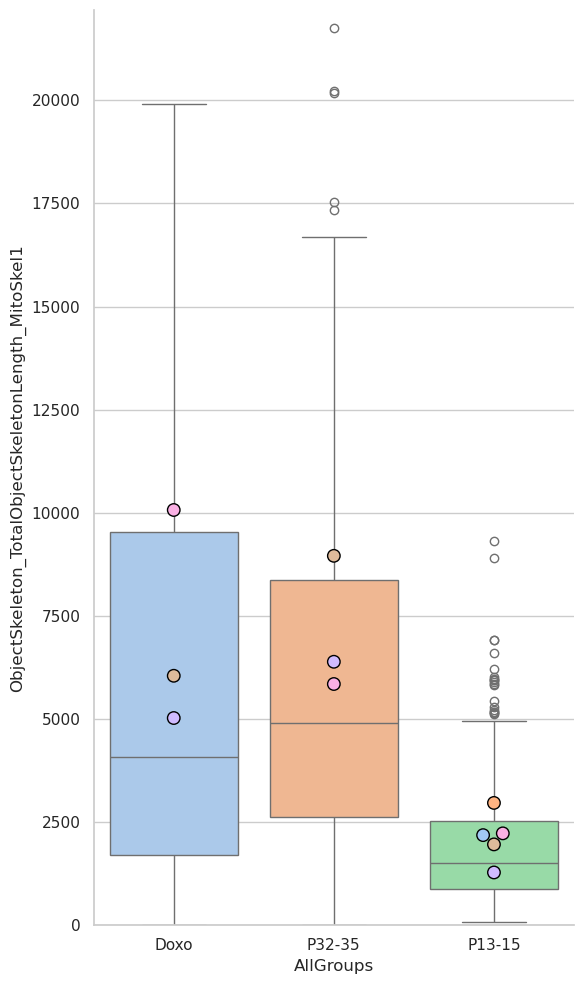

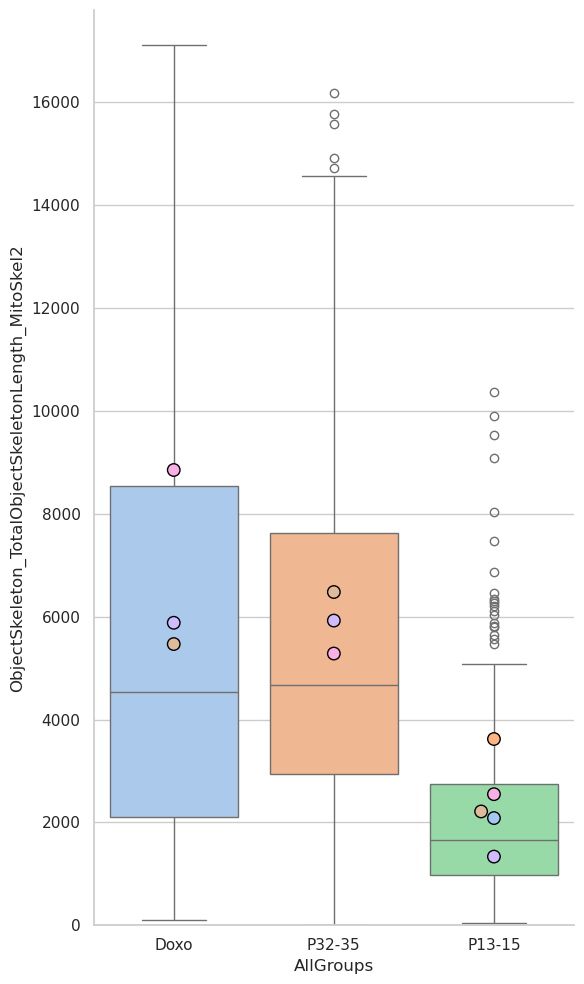

In [14]:


feature_cols = use_cols_unique[4:]
colour_dict = get_hard_code_plate_colours(
    combined_cell_df_mitolyso2, ["1", "2", "3", "4", "5", "6", "7"], "Metadata_PlateNumber"
)
def plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict=colour_dict, size=(6, 10)):
    outpath = "segmentation_test/plots"
    os.makedirs(outpath, exist_ok=True)
    for col in feature_cols:
        plt.figure(figsize=size)
        sns.set_style("whitegrid")
        sns.set_context("notebook")
        sns.boxplot(display_df, x="AllGroups", y=col, palette="pastel" , fill=True, hue="AllGroups", legend=False)
        sns.swarmplot(display_df_pivot_plates, x="AllGroups", y=col, palette=colour_dict,hue="Metadata_PlateNumber", dodge=False, size = 9, legend=False, linewidth=1, edgecolor="k" )
        sns.despine()
        plt.ylim(0, np.percentile(display_df[col].dropna(), 99)*1.1)  
        plt.tight_layout()
        plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
        plt.show()
        
# def plot_boxplots_with_swarm_pairs(
#     display_df,
#     display_df_pivot_plates,
#     feature_cols,
#     colour_dict=colour_dict,
#     size=(6, 10),
# ):
#     outpath = "segmentation_test/pairedplots"
#     os.makedirs(outpath, exist_ok=True)
#     for col in feature_cols:
#         fig, axes = plt.subplots(1, 2, figsize=(figsize[0] * 2, figsize[1]), sharey=True)

#         for ax, suffix in zip(axes, ["1", "2"]):
#             item = rows[suffix]
#         sns.set_style("whitegrid")
#         sns.set_context("notebook")
#         ax = plt.gca()
#         ax = sns.boxplot(
#             display_df,
#             x="AllGroups",
#             y=col,
#             palette="pastel",
#             fill=True,
#             hue="AllGroups",
#             legend=False,
#         )
#         sns.swarmplot(
#             display_df_pivot_plates,
#             x="AllGroups",
#             y=col,
#             palette=colour_dict,
#             hue="Metadata_PlateNumber",
#             dodge=False,
#             size=9,
#             legend=False,
#             linewidth=1,
#             edgecolor="k",
#         )
#         sns.despine()
#         plt.ylim(0, np.percentile(display_df[col].dropna(), 99) * 1.1)
#         plt.tight_layout()
#         plt.savefig(os.path.join(outpath, f"{col}_boxplot.png"))
#         plt.show()

plot_boxplots_with_swarm(display_df, display_df_pivot_plates, feature_cols, colour_dict, size=(6, 10))


# Define the cell features


## Feature lists here:

In [ ]:
feature_dicts = [mito_features, lyso_features, nuc_features, cell_features]
feature_names = [
    "Mitochondria Features",
    "Lysosome Features",
    "Nucleus Features",
    "Cell Features",
]

# Define the output file path
output_file_path = "allfeatures_file.md"

# Open the file in write mode
with open(output_file_path, "w") as file:
    for feature_name, feature_dict in zip(feature_names, feature_dicts):
        file.write(f"# {feature_name}\n\n")
        for feature_type, features in feature_dict.items():
            file.write(f"## {feature_type.capitalize()}\n")
            for feature in features:
                file.write(f'"{feature}",\n')
            file.write("\n")

print(f"List has been written to {output_file_path}")


## Normalize features to control (Passage 6-8)

In [ ]:
# updated/faster version that doesn't use apply and is much faster for large dataframes
all_valid_features = []
for feat_dict in feature_dicts:
    all_cols = [col for cols in feat_dict.values() for col in cols]
    for col in set(all_cols):
        if pd.api.types.is_numeric_dtype(extrafeatures_filtered_cell_df_mitolyso[col]):
            all_valid_features.append(col)
valid_feature_cols = list(
    dict.fromkeys(all_valid_features)
)  # remove duplicates while preserving order
group_col = "AgeGroup"
control_value = 0
norm_combined_cell_df_mitolyso = normalize_quantities_to_control_group_average(
    extrafeatures_filtered_cell_df_mitolyso.copy(),
    valid_feature_cols,
    group_col,
    control_value,
    overwrite=True,
    drop_avg_cols=True,
)
# display(
#     norm_combined_cell_df_mitolyso[
#         ["AllGroups", "Plate_Number", "Metadata_Well"]
#         + valid_feature_cols
#     ]
# )
# norm_combined_cell_df_mitolyso.boxplot(column="Mean_Lysosomes_Distance_Centroid_Cell", by="AllGroups")
# norm_combined_cell_df_mitolyso.groupby(["Plate_Number", "AllGroups"])[
#     "Mean_Lysosomes_Distance_Centroid_Cell"
# ].describe()

In [ ]:
def allgroups_sort_key(value):
    """Custom sort key function for 'AllGroups' column."""
    import re

    match = re.match(r"P(\d+)", value)
    if match:
        first_number = match.group(1)
        if first_number.isdigit():
            return int(first_number)
        else:
            return 99999
    return 99999


print(allgroups_sort_key("P6-10"))

## Helper functions for plot building

In [ ]:
def annotate_pairs_with_calculated_pvalues_test(
    ax,
    data,
    pivot_data,
    x_value,
    y_value,
    plate_col_name="Plate_Name",
    test_name="tukey",
    pairs=None,
    order=None,
    plot_type="violinplot",
    show_test_name=False,
    p_correction="fdr_bh",
    annotation_location="inside",
):
    """Add statistical annotations to a plot using a multiple comparisons test in the statsmodels, scipy, or scikit-posthocs modules.
    see https://statannotations.readthedocs.io/en/latest/custom-test.html for more examples
    Also see https://www.graphpad.com/guides/prism/latest/statistics/stat_summary_of_multiple_comparison.htm for a list of posthoc tests and when to use them

    Args:
        ax (Matplotlib Axes Object): the axis of the graph to annoate
        data (DataFrame): dataframe from a grouped feature df containing the groups aggregated by plate to analyze in "tidy" format
        pivot_data (DataFrame): the grouped feature df in matrix format
        x_value (str): independent variable on x axis
        y_value (str): dependent variable on y axis
        plate_col_name (str, optional): the col containing the experimental plate. Defaults to "Plate_Name".
        test_name (str, optional): the statistical test to perform. Accepts values of "tukey", "anova", or "tukey_v2", for ANOVA with Tukey's HSD, "tukey_v3" for ANOVA with Tukey HSD with Tukey-Kramer correction, "games-howell" or "games" for ANOVA with Games-Howell posthoc, "rmanova" for repeated-measures ANOVA using Welch's ttest with the specified p-value correction, "kruskal" or "dunn" for classic nonparametric multiple comparisons with Dunn's postc, "conover" for kruskal with Conover's posthoc, "nemenyi" for kruskal (or friedman) with Nemenyi's posthoc for repeated measures, "pairwise_ttest" for corrected ttests, "pairwise_mwu" for nonparametic multiple comparisons. Defaults to "tukey".
        pairs (list of str, optional): The pairs of x_value for the comparisons. Defaults to None, is automatically calculated otherwise based on the getpairs() function.
        order (listlike, optional): _description_. Defaults to None.
        plot (str, optional): the type of plot to annotate. Defaults to "violinplot".
        p_correction (str, optional): the p-value correction to use if applicable. Deaults to Benjamini/Hochberg "fdr_bh" (non-negative) method ; graphpad reccomneds as its less hemmoraging to your power. Also accepts "holm", "sidak", "bonferroni", "holm-sidak" and Benjamini/Yekutieli "fdr-by" for negative values. See https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_mannwhitney.html for other options

    Returns:
        _type_: _description_
    """
    from statannotations.Annotator import Annotator

    if pairs is None:
        pairs = getpairs(data, x_value, order=order)

    # nonparametric tests
    if test_name in ["kruskal", "dunn", "kruskal-wallis"]:
        used_pairs, p_values = kruskal_with_dunn_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["drubin", "drubin_posthoc"]:
        used_pairs, p_values = kruskal_with_drubin_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["conover", "con", "kruskal-conover"]:
        used_pairs, p_values = kruskal_with_conover_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_correction=p_correction,
            display_results=True,
        )
    elif test_name in ["nemenyi", "kruskal-nemenyi"]:
        used_pairs, p_values = kruskal_with_nemenyi_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
            p_correction=p_correction,
        )
    # parametric tests
    elif test_name in ["anova", "tukey", "tukeyhsd"]:
        # perform anova and tukey's post-hoc test
        used_pairs, p_values = pvalues_anova_and_tukeyhsd_posthoc(
            data, pivot_data, x_value, y_value, order=order, desired_pairs=pairs
        )
    elif test_name in ["games", "games-howell"]:
        used_pairs, p_values = pvalues_anova_with_games_howell_pingouin(
            data,
            pivot_data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["tahmane", "tahmane-t2"]:
        used_pairs, p_values = anova_with_tahmane_posthoc(
            data,
            x_value,
            y_value,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v2", "tukey_posthocs"]:
        used_pairs, p_values = anova_with_tukey_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display_results=True,
        )
    elif test_name in ["tukey_v3", "tukey_pingouin"]:
        used_pairs, p_values = pvalues_anova_with_tukey_pingouin(
            data,
            pivot_data,
            x_value=x_value,
            y_value=y_value,
            plate_number_col=plate_col_name,
            order=order,
            desired_pairs=pairs,
            display=True,
        )
    elif test_name in ["pairwise_ttest" or "multiple_ttest"]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=True,
            display=True,
        )
    elif test_name in [
        "pairwise_mwu"
        or "multiple_mwu"
        or "pairwise_mannwhitney"
        or "multiple_mannwhitney"
        or "pairwise_wilcoxon"
        or "multiple_wilcoxon"
    ]:
        used_pairs, p_values = pvalues_anova_with_pairwise_tests_pingouin(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            pval_correction=p_correction,
            parametric=False,
            display=True,
        )
    elif test_name in ["ttest_posthoc", "welch's_posthoc", "tt_posthoc"]:
        used_pairs, p_values = anova_with_corr_ttest_posthoc(
            data,
            x_value=x_value,
            y_value=y_value,
            order=order,
            desired_pairs=pairs,
            p_corr=p_correction,
            display_results=True,
        )
    else:
        raise ValueError(
            f"Test name '{test_name}' is invalid. Use 'tukey', 'anova', 'kruskal', 'games-howell', 'drubin', 'tukey_v2', or 'dunn'."
        )
    if used_pairs is None or len(used_pairs) == 0:
        print(f"No significant pairs found for the {test_name} test.")
        return ax
    else:
        annotator = Annotator(
            ax=ax,
            pairs=list(used_pairs),
            data=data,
            plot=plot_type,
            x=x_value,
            y=y_value,
            order=order,
        )
        annotator.reset_configuration()
        # see https://raw.githubusercontent.com/trevismd/statannotations/3f020ae631ca88a091b6ee3e9a9fd32158920879/usage/example_tuning_y_offsets_w_arguments.png
        annotator.configure(
            text_format="full",
            test_short_name=test_name,
            pvalue_format_string="{:.4f}",
            fontsize="small",
            # pvalue_format = [[1e-5, "1e-5"], [1e-4, "1e-4"], [1e-3, "0.001"], [1e-2, "0.01"], [5e-2, "0.05"]],
            loc=annotation_location,
            hide_non_significant=True,
            color="black",
            verbose=2,
            line_height=0.01,
            text_offset=0.8,
            # line_offset_to_group=0.01,
            # line_offset=0.01,
            show_test_name=show_test_name,
        )
        annotator.set_pvalues_and_annotate(p_values)
        return ax


def super_splitviolinplot_helper_singleplot(
    data_df,
    group_avg_df,
    ax,
    x_value,
    y_value,
    title,
    plate_col_name,
    pairs=None,
    order=None,
    annotate=False,
    test=None,
    shapiro=True,
    show_test_on_plot=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    group_avg_df = group_avg_df.copy()
    if pairs is None:
        pairs = getpairs(data_df, x_value, order=order)

    if pallete is None:
        pallete = get_hard_code_plate_colours(group_avg_df)
    print(pairs)
    sns.violinplot(
        data=data_df,
        x=x_value,
        y=y_value,  # hue=x_value,
        # palette="Set2",
        split=True,  # using split violin plots - only one side, basically looks like a histogram
        inner="quart",
        color="gainsboro",
        dodge=False,
        # fill = True
        width=1,
        linewidth=1.5,
        order=order,
        ax=ax,
        cut=0.5,
    )
    # add in the colour scheme
    unique_plates = group_avg_df[plate_col_name].unique()
    group_avg_df[plate_col_name] = pd.Categorical(
        group_avg_df[plate_col_name], categories=unique_plates
    )
    sns.swarmplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        hue=plate_col_name,
        order=order,
        palette=pallete,
        size=10,
        edgecolor="k",
        linewidth=1,
        dodge=False,
        ax=ax,
    )
    # draw a boxplot to show the mean line
    sns.boxplot(
        data=group_avg_df,
        x=x_value,
        y=y_value,
        showmeans=True,
        meanline=True,
        meanprops={"color": "dimgray", "ls": "-", "lw": 4},
        medianprops={"visible": False},
        whiskerprops={"visible": False},
        zorder=2,
        showfliers=False,
        showbox=False,
        showcaps=False,
        ax=ax,
    )
    ax.set_title(title)

    # use pivot table to get the average values for each group
    if annotate and test is not None:
        group_avg_pivot_table = average_groups_pivot(
            group_avg_df, x_value, y_value, plate_col_name
        )
        try:
            ax = annotate_pairs_with_calculated_pvalues_test(
                ax,
                group_avg_df,
                group_avg_pivot_table,
                x_value,
                y_value,
                plate_col_name=plate_col_name,
                test_name=test,
                order=order,
                plot_type="violinplot",
                show_test_name=show_test_on_plot,
                p_correction=p_correction,
                annotation_location=annotation_location,
            )
        except Exception as e:
            print(f"Error annotating with statistical test: {e}")
            # ax = annotate_with_anova_tukey(ax, pairs, group_avg_df_pivot, x_value, y_value, plate_col_name=plate_col_name, order=order, plot="violinplot")
        # elif test == "kruskal":
        #     ax = annotate_with_kruskal(
        #         ax,
        #         pairs,
        #         group_avg_pivot_table,
        #         x_value,
        #         y_value,
        #         order=order,
        #         plate_col_name=plate_col_name,
        #         plot="violinplot",
        #     )
        if shapiro:
            ax = annotate_legend_with_shapiro(ax, group_avg_df, plate_col_name)

    return ax


def single_feature_super_splitviolinplot(
    data_df,
    x_value="AllGroups",
    y_value="Cell_AreaShape_Area",
    plate_col_name="Plate_Number",
    out_dir=Path(""),
    xtitle=None,
    ytitle=None,
    order=None,
    legend=True,
    annotate=False,
    test=None,
    show_hist=False,
    remove_outliers=False,
    rm_outliers_method="mad",
    ylim=None,
    reps_to_exclude=[],
    shapiro=True,
    show=True,
    context="talk",
    font_scale=1.2,
    figsize=(8, 6),
    truncate_outliers=False,
    norm=False,
    pallete=None,
    p_correction="bonf",
    annotation_location="inside",
):
    """Make a superplot to do multiple comparisons for a feature between different conditions
    Args:
        data_df_1 (_type_): _description_
        group_avg_df_1 (_type_): _description_
        data_df_2 (_type_): _description_
        group_avg_df_2 (_type_): _description_
        x_value (str, optional): _description_. Defaults to "AllGroups".
        y_value (str, optional): _description_. Defaults to "Cell_AreaShape_Area".
        plate_col_name (str, optional): _description_. Defaults to "Plate_Number".
        csv_dir (str, optional): _description_. Defaults to "".
        xtitle (_type_, optional): _description_. Defaults to None.
        ytitle (_type_, optional): _description_. Defaults to None.
    """
    import matplotlib.lines as mlines
    from statannotations.Annotator import Annotator
    from statannotations.stats.StatTest import StatTest
    from pathlib import Path

    if order == None:
        order = get_all_group_order()
    pairs = getpairs(data_df, x_value, order=order)
    print(pairs)
    if truncate_outliers:
        try:
            bottom_fence = None  # np.percentile(data_df[y_value], 0.000001)
            if norm:
                top_fence = data_df[y_value].mean() + 10 * data_df[y_value].std()
            else:
                top_fence = np.percentile(data_df[y_value], 99.9)
                # handle errors where the data is very skewed and the percentile is inf or nan
                if top_fence == 0 or np.isnan(top_fence) or np.isinf(top_fence):
                    top_fence = None
            axlim = (bottom_fence, top_fence)
        except ValueError as e:
            print(e)
            top_fence = None
            bottom_fence = None
            axlim = (None, None)
    else:
        axlim = (None, None)

    df_sorted = data_df.sort_values(
        by=[x_value], key=lambda x: x.map(passage_groups_sort_key)
    ).reset_index(drop=True)
    if show_hist:
        hist = sns.kdeplot(
            df_sorted, x=y_value, hue=plate_col_name, palette=pallete, multiple="layer"
        )
        plt.xlim(axlim)
        plt.savefig(f"{Path(out_dir, f'{y_value}_{plate_col_name}_histogram')}.png")
        plt.show()
        plt.close()
        hist2 = seaborn_ridgeplot(
            df_sorted,
            value_col=y_value,
            group_col=x_value,
            palette="Set2",
            save=True,
            out_dir=out_dir,
            show_percentiles=True,
        )
        plt.close()
    fig, ax = plt.subplots(figsize=figsize)
    sns.set_theme(style="ticks", context=context, font_scale=font_scale)

    feature_df = df_sorted[[x_value, y_value, plate_col_name]].copy()
    if reps_to_exclude:
        feature_df = feature_df[~feature_df[plate_col_name].isin(reps_to_exclude)]
        print(f"removing plates: {reps_to_exclude}")

    # remove outluers
    if remove_outliers is True:
        if rm_outliers_method == "mad":
            feature_df = flag_outliers_by_group_mad(feature_df, x_value, y_value)
            feature_df = feature_df[~feature_df["Outlier"]]
        elif rm_outliers_method == "gesd":
            feature_df = flag_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=50
            )
            feature_df = feature_df[~feature_df["Outlier_GESD"]]
        elif rm_outliers_method == "gesd_2":
            print(feature_df.shape)
            feature_df = remove_outliers_by_group_gesd(
                feature_df, x_value, y_value, noutliers=500
            )
            print(feature_df.shape)
        elif rm_outliers_method == "tietjen":
            feature_df = remove_outliers_by_group_tietjen(
                feature_df, x_value, y_value, noutliers=50
            )
        elif rm_outliers_method == "iqr":
            feature_df = remove_outliers_iqr(feature_df)
        else:
            ValueError(f"{rm_outliers_method} is not a valid outlier removal method")
        # display(feature_df)

    # group by plate and condition
    group_avg_df = feature_df.groupby([x_value, plate_col_name], as_index=False).mean()
    # sort the group avg df by the "AllGroups" order
    group_avg_df_sorted = group_avg_df.sort_values(
        by=[x_value], key=lambda x: x.map(allgroups_sort_key)
    ).reset_index(drop=True)

    ax = super_splitviolinplot_helper_singleplot(
        feature_df,
        group_avg_df_sorted,
        ax,
        x_value,
        y_value,
        title=" ",
        plate_col_name=plate_col_name,
        pairs=pairs,
        order=order,
        annotate=annotate,
        test=test,
        shapiro=False,
        pallete=pallete,
        p_correction=p_correction,
        annotation_location=annotation_location,
    )

    if legend:
        ax.legend(
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            frameon=True,
            title=plate_col_name,
        )
        if shapiro:
            group_avg_df_shapiro = apply_shapiro_wilk_test_to_df(
                group_avg_df_sorted,
                feature_meas=y_value,
                plate_col_name="Plate_Number",
                alpha=0.05,
            )
            # display(group_avg_df_shapiro)
            ax = annotate_legend_with_shapiro(ax, group_avg_df_shapiro, plate_col_name)
    else:
        ax.legend_.remove()
    if ytitle is not None:
        ax.set_ylabel(ytitle)
    else:
        ax.set_ylabel(y_value.replace("_", " "))
    if xtitle is not None:
        ax.set_xlabel(xtitle)

    # Set the ylim and don't throw an inf
    if ylim is None:
        ylim = axlim
    if ylim[0] is not None and ylim[1] is not None:
        if not (
            np.isnan(ylim[0])
            or np.isnan(ylim[1])
            or np.isinf(ylim[0])
            or np.isinf(ylim[1])
        ):
            ax.set_ylim(ylim)
    plt.tight_layout()
    sns.despine(trim=True)
    plt.savefig(os.path.join(out_dir, f"{y_value}_{test}.png"))
    if show:
        plt.show()

## Make a plot for a single feature

In [ ]:
order = get_all_group_order()
feature_meas = "AreaShape_Area"  # "AreaShape_Area"#Mean_Lysosomes_Distance_Centroid_Nuclei_PerCell_Area" #Mean_Lysosomes_DiameterRatio_PerCell"
ylabel = None  # "Mitochondrial Density Per Cell (relative to youngest passage)"#None#"Mitochondria per cell"
xlabel = "Age Groups"
group = "AllGroups"

pairs = getpairs(combined_cell_df_mitolyso, group, order)

# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()
this_df = norm_combined_cell_df_mitolyso.copy()

data_df = this_df  # >3500]   #Potentially use a theshold - this is the trough of the nuc size peak at 0
# this_df = extrafeatures_filtered_cell_df_mitolyso.copy()

# Map each plate to a color and hard code that shit
colour_dict = get_hard_code_plate_colours(data_df)
pallete = colour_dict  # "pastel"

remove_outliers = False
reps_to_exclude = []
plot_dir = "plots/notnorm"
os.makedirs(plot_dir, exist_ok=True)

figsize = (13, 12)

single_feature_super_splitviolinplot(
    data_df,
    x_value=group,
    y_value=feature_meas,
    plate_col_name="Plate_Number",
    xtitle=xlabel,
    ytitle=ylabel,
    out_dir=plot_dir,
    annotate=True,
    order=order,
    test="tukey_v3",
    reps_to_exclude=reps_to_exclude,
    show_hist=False,  # True,
    remove_outliers=remove_outliers,
    rm_outliers_method="gesd_2",
    truncate_outliers=True,
    legend=True,
    context="talk",
    font_scale=0.8,
    figsize=figsize,
    pallete=pallete,
    p_correction="fdr_bh",
    annotation_location="inside",
    # truncate_outliers=True
)

# NOTE: R5 has smallest cells in p23-25, which is also highest mito density

## Make multiple plots as defined

In [ ]:
# take feature : label pairs to be used for plots from csv
features_df = pd.read_csv("CP_features_for_plots.csv")
display(features_df[features_df["feature"] == "AreaShape_Area"])

data_df = extrafeatures_filtered_cell_df_mitolyso.copy()
# Use in plotting loops with guaranteed alignment:


def make_feature_plots_from_csv(
    data_df,
    features_df,
    xlabel="Age Groups",
    group="AllGroups",
    analysis_mode="Plates",
    norm=False,
    order=None,
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(14, 18),
    truncate_outliers=True,
    rm_outliers_method="gesd_2",
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
    show_legend=False,
):
    features_for_plots = features_df.to_dict("records")

    feature_df_cols = [item["feature"] for item in features_for_plots]
    feature_labels = [item["label"] for item in features_for_plots]

    if order is None:
        order = get_all_group_order()
    pairs = getpairs(data_df, group, order)

    # Set stats variables and color palette based on analysis mode
    if analysis_mode == "Lineages":
        stat_grouping = "Lineage"
        plot_dir = Path("plots/lineages")
        show_legend = True
        colour_dict = get_hard_code_lineage_colours(data_df)
    elif analysis_mode == "Plates":
        stat_grouping = "Plate_Number"
        colour_dict = get_hard_code_plate_colours(data_df)
        if norm:
            data_df = norm_combined_cell_df_mitolyso.copy()
            feature_labels = [
                f"{name} (normalized to youngest group)" for name in feature_labels
            ]
            plot_dir = Path("plots/norm")
        else:
            data_df.copy()
            data_df = data_df[data_df["MitoEnds_NumberBranchEnds_PerCell_Area"] > 0]
            plot_dir = Path("plots/notnorm")
            
    else:
        raise ValueError(
            f"Invalid analysis mode: {analysis_mode}. Use 'Lineages' or 'Plates'."
        )
    pallete = colour_dict  # "pastel"

    os.makedirs(plot_dir, exist_ok=True)
    for i, feature in enumerate(feature_df_cols):
        ylabel = feature_labels[i]

        single_feature_super_splitviolinplot(
            data_df,
            x_value=group,
            y_value=feature,
            plate_col_name=stat_grouping,
            xtitle=xlabel,
            ytitle=ylabel,
            out_dir=plot_dir,
            annotate=annotate_pval,
            order=order,
            test=test,
            reps_to_exclude=reps_to_exclude,
            show_hist=False,  # True,
            remove_outliers=remove_outliers,
            rm_outliers_method=rm_outliers_method,
            truncate_outliers=truncate_outliers,
            legend=show_legend,
            context="talk",
            figsize=figsize,
            pallete=pallete,
            p_correction="fdr_bh",
            shapiro=False,
            font_scale=font_scale,
            annotation_location=annotation_location,
        )


make_feature_plots_from_csv(
    data_df,
    features_df,
    norm=True,
    analysis_mode="Plates",
    remove_outliers=False,
    reps_to_exclude=[],
    figsize=(13, 12),
    annotate_pval=True,
    test="tukey_v3",
    font_scale=0.8,
    annotation_location="inside",
)